# Avalon E1 — Llama 3.1 8B Sweep Results

**Model**: Llama 3.1 8B Instruct (`meta-llama/Meta-Llama-3.1-8B-Instruct`, `think=False`, SGLang FP8)  
**Game**: Avalon (5-player: LLM as Player 0, 4 naive bots)  
**Summarizer**: Sonnet (`claude-sonnet-4-6`) — structured public-knowledge summary after each quest  
**Backend**: SGLang constrained decoding — two-pass: free reasoning up to B tokens, then regex-forced choice  

---

## Experiment cells

| ID | Role | Prompt | B | Disc | N | Label |
|---|---|---|---|---|---|---|
| L-S-min-low | Servant | minimal | 64 | ✗ | 50 | `avalon_e1_servant_minimal` |
| L-S-min-high | Servant | minimal | 1024 | ✗ | 50 | `avalon_e1_servant_minimal` |
| L-S-proc-low | Servant | procedural | 64 | ✗ | 50 | `avalon_e1_servant_procedural` |
| L-S-proc-high | Servant | procedural | 1024 | ✗ | 50 | `avalon_e1_servant_procedural` |
| L-M-min-high | Merlin | minimal | 1024 | ✗ | 30 | `avalon_e1_merlin` |
| L-M-proc-high | Merlin | procedural | 1024 | ✗ | 30 | `avalon_e1_merlin_procedural` |
| L-S-min-disc-high | Servant | minimal | 1024 | ✓ | 30 | `avalon_e1_servant_minimal_disc` |
| L-S-min-disc-low | Servant | minimal | 64 | ✓ | 30 | `avalon_e1_servant_minimal_disc_low` |
| L-M-min-disc-high | Merlin | minimal | 1024 | ✓ | 30 | `avalon_e1_merlin_minimal_disc` |

**Note**: disc cells are P2-B surplus (qualitative data only — budget-confounded, not primary comparisons).  
All runs: `started_at > 2026-05-22T07:40`, `with_summarizer=True`, `0 errors`.

In [1]:
import json
import sqlite3
from pathlib import Path
from math import comb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

ROOT = Path('..') if Path('..').joinpath('src').exists() else Path('.')
DB_PATH = ROOT / 'data' / 'results.db'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.6,
    'figure.dpi': 120,
})

print('DB path:', DB_PATH.resolve())
print('DB exists:', DB_PATH.exists(), f'({DB_PATH.stat().st_size / 1e6:.1f} MB)' if DB_PATH.exists() else '')

DB path: /home/stephone/Development/CoT-difficulty-knob/data/results.db
DB exists: True (31.3 MB)


In [2]:
# ── Load valid runs from SQLite ────────────────────────────────────────────────
# Valid = ran after 2026-05-22T07:40 (after summarizer bug fix), 0 errors
# llamasumm run is excluded here — it is loaded separately in the L-S-llamasumm section.

conn = sqlite3.connect(DB_PATH)

trials_df = pd.read_sql_query("""
    SELECT
        r.name            AS run_name,
        t.trial_id,
        t.condition_json,
        t.winner,
        t.final_score_llm,
        t.final_score_uct,
        t.n_turns_total,
        t.n_llm_turns,
        t.n_tokens_llm_total,
        t.seed
    FROM runs r
    JOIN trials t ON t.run_id = r.run_id
    WHERE r.started_at > '2026-05-22T07:40'
      AND r.name NOT LIKE 'smoke%'
      AND r.name NOT LIKE 'avalon_e1_servant_llamasumm%'
    ORDER BY r.started_at, t.seed
""", conn)

summaries_df = pd.read_sql_query("""
    SELECT
        r.name AS run_name,
        s.trial_id,
        s.summary_id,
        s.after_turn_idx,
        s.n_tokens_est,
        s.summary_text
    FROM runs r
    JOIN trials t ON t.run_id = r.run_id
    JOIN summaries s ON s.trial_id = t.trial_id
    WHERE r.started_at > '2026-05-22T07:40'
      AND r.name NOT LIKE 'smoke%'
      AND r.name NOT LIKE 'avalon_e1_servant_llamasumm%'
""", conn)

conn.close()

# Parse condition_json into columns
cond = trials_df['condition_json'].apply(json.loads)
trials_df['budget']          = cond.apply(lambda c: c['budget'])
trials_df['llm_role']        = cond.apply(lambda c: c['llm_role'])
trials_df['prompt_variant']  = cond.apply(lambda c: c['prompt_variant'])
trials_df['with_discussion']  = cond.apply(lambda c: c.get('with_discussion', False))
trials_df['bot_strategy']     = cond.apply(lambda c: c.get('bot_strategy', 'naive'))
trials_df['shuffle_all_roles']= cond.apply(lambda c: c.get('shuffle_all_roles', False))
trials_df['llm_win']          = (trials_df['winner'] == 'llm').astype(int)
trials_df['bots_win']         = (trials_df['winner'] == 'bots').astype(int)

print(f'Loaded {len(trials_df)} trials across {trials_df["run_name"].nunique()} runs')
print(f'Loaded {len(summaries_df)} summaries')
print()

# Quick sanity: errors
err = trials_df[trials_df['winner'] == 'error']
print(f'Error trials: {len(err)} (expected 0)')
print()
print(trials_df.groupby(['run_name', 'budget'])[['llm_win', 'bots_win']].agg(['sum', 'count']).to_string())

Loaded 350 trials across 7 runs
Loaded 1285 summaries

Error trials: 0 (expected 0)

                                          llm_win       bots_win      
                                              sum count      sum count
run_name                           budget                             
avalon_e1_merlin                   1024         0    30       30    30
avalon_e1_merlin_minimal_disc      1024         0    30       30    30
avalon_e1_merlin_procedural        1024         0    30       30    30
avalon_e1_servant_minimal          64           0    50       50    50
                                   1024         1    50       49    50
avalon_e1_servant_minimal_disc     1024         1    30       29    30
avalon_e1_servant_minimal_disc_low 64           0    30       30    30
avalon_e1_servant_procedural       64           0    50       50    50
                                   1024         4    50       46    50


In [3]:
# ── Helper: Wilson CI + binomial p-value ───────────────────────────────────────

def wilson_ci(wins: int, n: int, alpha: float = 0.05):
    if n == 0:
        return np.nan, np.nan, np.nan
    z = stats.norm.ppf(1 - alpha / 2)
    p = wins / n
    denom = 1 + z**2 / n
    center = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return p, max(0.0, center - half), min(1.0, center + half)


def binom_pval_vs_null(wins: int, n: int, null_p: float = 0.0) -> float:
    """One-sided binomial p-value: P(X >= wins | p=null_p)."""
    if n == 0:
        return 1.0
    return sum(
        comb(n, k) * (null_p**k) * ((1 - null_p)**(n - k))
        for k in range(wins, n + 1)
    )


def win_rate_table(df: pd.DataFrame, group_cols: list) -> pd.DataFrame:
    rows = []
    for keys, grp in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        n    = len(grp)
        wins = int(grp['llm_win'].sum())
        p, lo, hi = wilson_ci(wins, n)
        pval = binom_pval_vs_null(wins, n, null_p=0.0)
        row = dict(zip(group_cols, keys))
        row.update({'n': n, 'wins': wins, 'win_rate': p, 'ci_lo': lo, 'ci_hi': hi, 'pval': pval})
        rows.append(row)
    return pd.DataFrame(rows)


# Master win-rate table grouped by run + budget
wr = win_rate_table(trials_df, ['run_name', 'llm_role', 'prompt_variant', 'with_discussion', 'budget'])
wr = wr.sort_values(['llm_role', 'prompt_variant', 'with_discussion', 'budget'])

print('Win-rate table (all conditions):')
print(wr[['run_name', 'budget', 'n', 'wins', 'win_rate', 'ci_lo', 'ci_hi', 'pval']].to_string(
    index=False, float_format='{:.3f}'.format))

Win-rate table (all conditions):
                          run_name  budget  n  wins  win_rate  ci_lo  ci_hi  pval
                  avalon_e1_merlin    1024 30     0     0.000  0.000  0.114 1.000
     avalon_e1_merlin_minimal_disc    1024 30     0     0.000  0.000  0.114 1.000
       avalon_e1_merlin_procedural    1024 30     0     0.000  0.000  0.114 1.000
         avalon_e1_servant_minimal      64 50     0     0.000  0.000  0.071 1.000
         avalon_e1_servant_minimal    1024 50     1     0.020  0.004  0.105 0.000
avalon_e1_servant_minimal_disc_low      64 30     0     0.000  0.000  0.114 1.000
    avalon_e1_servant_minimal_disc    1024 30     1     0.033  0.006  0.167 0.000
      avalon_e1_servant_procedural      64 50     0     0.000  0.000  0.071 1.000
      avalon_e1_servant_procedural    1024 50     4     0.080  0.032  0.188 0.000


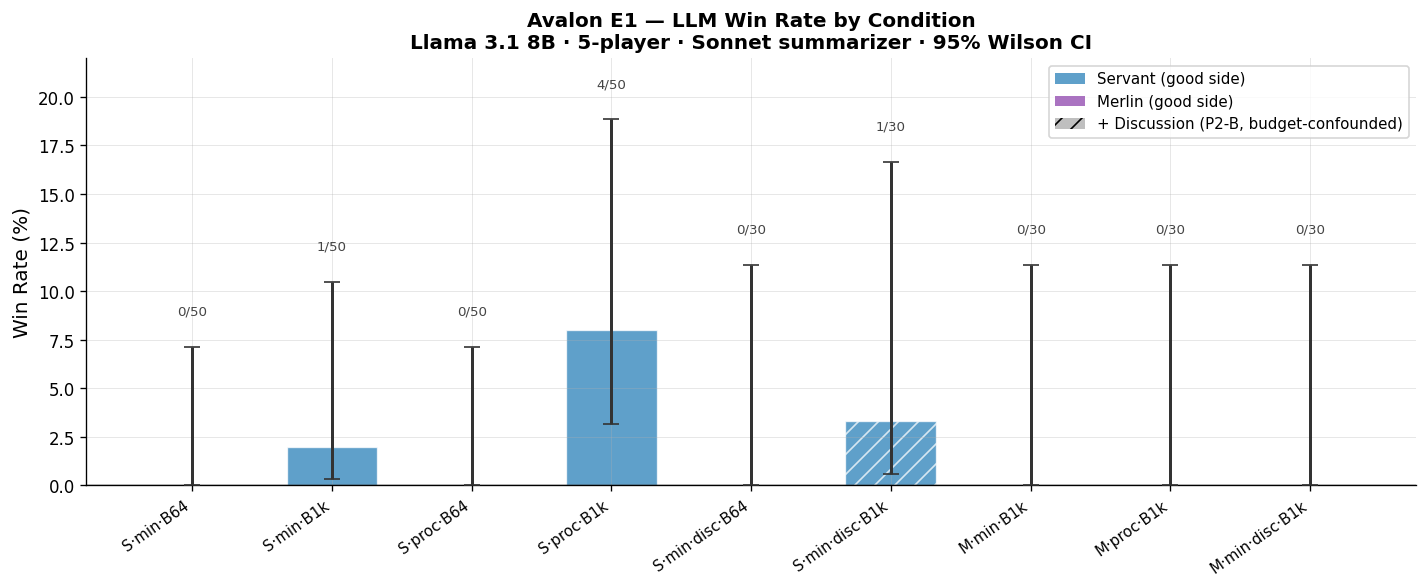

Saved: fig_e1_winrate_overview.png


In [4]:

# ── Figure 1: Win rate across all conditions ───────────────────────────────────

ROLE_COLORS = {'Servant': '#2980b9', 'Merlin': '#8e44ad'}
DISC_HATCH  = '//'

# Build ordered labels for the bar chart
label_map = {
    ('Servant', 'minimal',    False, 64):   'S·min·B64',
    ('Servant', 'minimal',    False, 1024):  'S·min·B1k',
    ('Servant', 'procedural', False, 64):   'S·proc·B64',
    ('Servant', 'procedural', False, 1024):  'S·proc·B1k',
    ('Servant', 'minimal',    True,  64):   'S·min·disc·B64',
    ('Servant', 'minimal',    True,  1024):  'S·min·disc·B1k',
    ('Merlin',  'minimal',    False, 1024):  'M·min·B1k',
    ('Merlin',  'procedural', False, 1024):  'M·proc·B1k',
    ('Merlin',  'minimal',    True,  1024):  'M·min·disc·B1k',
}

ordered_keys = list(label_map.keys())
wr_lookup = {}
for _, row in wr.iterrows():
    k = (row['llm_role'], row['prompt_variant'], bool(row['with_discussion']), int(row['budget']))
    wr_lookup[k] = row

fig, ax = plt.subplots(figsize=(12, 5))
xs      = np.arange(len(ordered_keys))
bar_w   = 0.65

for i, key in enumerate(ordered_keys):
    if key not in wr_lookup:
        continue
    row  = wr_lookup[key]
    if np.isnan(row['win_rate']):
        continue
    role = key[0]
    disc = key[2]
    color  = ROLE_COLORS[role]
    hatch  = DISC_HATCH if disc else ''
    wr_pct = float(row['win_rate']) * 100
    lo_err = max(0.0, (float(row['win_rate']) - float(row['ci_lo'])) * 100)
    hi_err = max(0.0, (float(row['ci_hi']) - float(row['win_rate'])) * 100)

    ax.bar(i, wr_pct, bar_w, color=color, alpha=0.75, hatch=hatch, edgecolor='white', linewidth=0.8)
    ax.errorbar(i, wr_pct, yerr=[[lo_err], [hi_err]],
                fmt='none', color='#333', elinewidth=1.8, capsize=5, zorder=5)
    ax.text(i, float(row['ci_hi']) * 100 + 1.5, f"{int(row['wins'])}/{int(row['n'])}",
            ha='center', va='bottom', fontsize=8, color='#444')

ax.set_xticks(xs)
ax.set_xticklabels([label_map[k] for k in ordered_keys], rotation=35, ha='right', fontsize=9)
ax.set_ylim(0, 22)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('Avalon E1 — LLM Win Rate by Condition\n'
             'Llama 3.1 8B · 5-player · Sonnet summarizer · 95% Wilson CI',
             fontsize=12, fontweight='bold')

# Legend
patches = [
    mpatches.Patch(facecolor=ROLE_COLORS['Servant'], alpha=0.75, label='Servant (good side)'),
    mpatches.Patch(facecolor=ROLE_COLORS['Merlin'],  alpha=0.75, label='Merlin (good side)'),
    mpatches.Patch(facecolor='gray', alpha=0.5, hatch=DISC_HATCH, label='+ Discussion (P2-B, budget-confounded)'),
]
ax.legend(handles=patches, fontsize=9, loc='upper right')
ax.axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig_e1_winrate_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_winrate_overview.png')


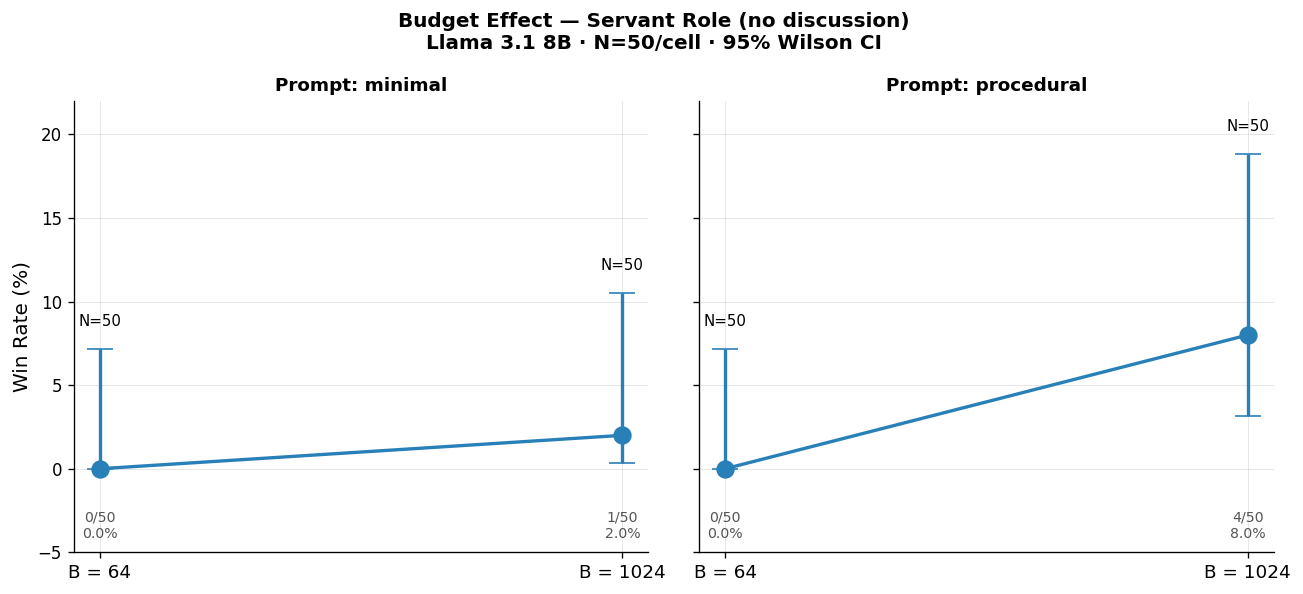

Saved: fig_e1_budget_effect.png


In [5]:

# ── Figure 2: Budget effect (B=64 vs B=1024) for Servant ──────────────────────

servant_no_disc = trials_df[
    (trials_df['llm_role'] == 'Servant') &
    (~trials_df['with_discussion'])
].copy()

wr_servant = win_rate_table(servant_no_disc, ['prompt_variant', 'budget'])

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

def _errbars(win_rates, ci_lo, ci_hi):
    lo = [max(0.0, (w - lo) * 100) for w, lo in zip(win_rates, ci_lo)]
    hi = [max(0.0, (hi - w) * 100) for hi, w in zip(ci_hi, win_rates)]
    return [lo, hi]

for ax, variant in zip(axes, ['minimal', 'procedural']):
    sub = wr_servant[wr_servant['prompt_variant'] == variant].sort_values('budget')
    win_rates = sub['win_rate'].tolist()
    ci_lo     = sub['ci_lo'].tolist()
    ci_hi     = sub['ci_hi'].tolist()
    ns        = sub['n'].tolist()

    ax.errorbar(
        [0, 1], [wr * 100 for wr in win_rates],
        yerr=_errbars(win_rates, ci_lo, ci_hi),
        fmt='o-', color=ROLE_COLORS['Servant'], ecolor=ROLE_COLORS['Servant'],
        elinewidth=2, capsize=8, markersize=10, linewidth=2, zorder=5
    )
    for xi, (wr, hi, n) in enumerate(zip(win_rates, ci_hi, ns)):
        ax.annotate(f"N={n}", (xi, hi * 100 + 1.2), ha='center', va='bottom', fontsize=9)
    for xi, (wr, wins, n) in enumerate(zip(win_rates, sub['wins'].tolist(), ns)):
        ax.annotate(f"{int(wins)}/{n}\n{wr*100:.1f}%", (xi, -2.5),
                    ha='center', va='top', fontsize=8.5, color='#555')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['B = 64', 'B = 1024'], fontsize=11)
    ax.set_title(f'Prompt: {variant}', fontsize=11, fontweight='bold')
    ax.set_ylim(-5, 22)
    if ax is axes[0]:
        ax.set_ylabel('Win Rate (%)', fontsize=12)

fig.suptitle('Budget Effect — Servant Role (no discussion)\n'
             'Llama 3.1 8B · N=50/cell · 95% Wilson CI', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_e1_budget_effect.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_budget_effect.png')


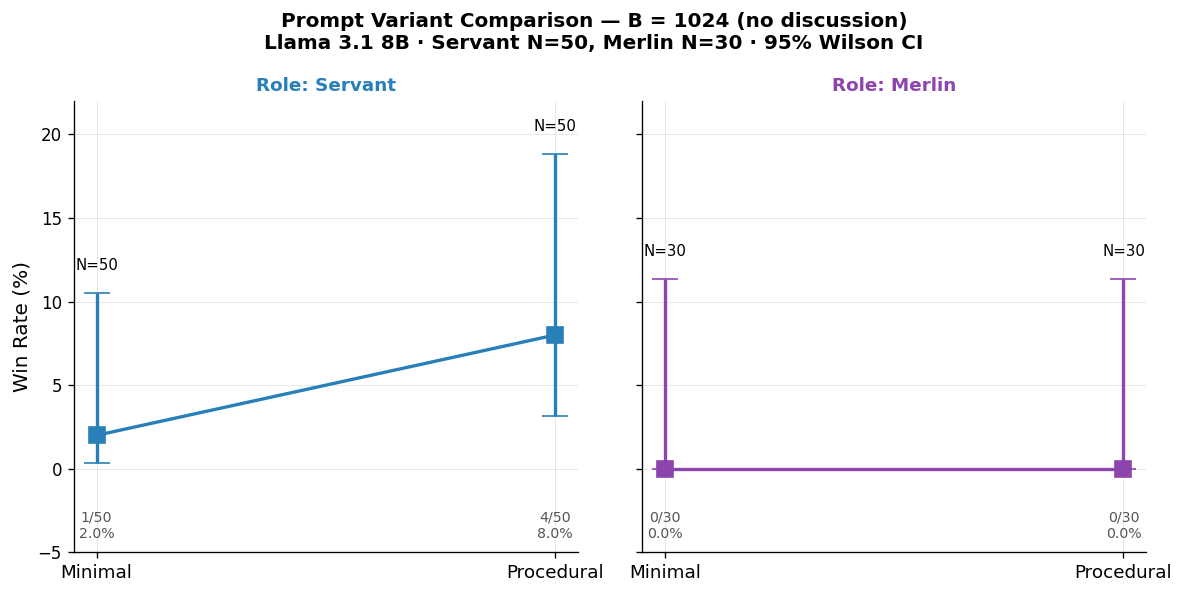

Saved: fig_e1_prompt_variant.png


In [6]:

# ── Figure 3: Prompt variant comparison (minimal vs procedural, B=1024) ────────

high_budget = trials_df[
    (trials_df['budget'] == 1024) &
    (~trials_df['with_discussion'])
].copy()

wr_variants = win_rate_table(high_budget, ['llm_role', 'prompt_variant'])
wr_variants = wr_variants.sort_values(['llm_role', 'prompt_variant'])

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, role in zip(axes, ['Servant', 'Merlin']):
    sub      = wr_variants[wr_variants['llm_role'] == role].sort_values('prompt_variant')
    color    = ROLE_COLORS[role]
    wrs      = sub['win_rate'].tolist()
    los      = sub['ci_lo'].tolist()
    his      = sub['ci_hi'].tolist()
    ns       = sub['n'].tolist()
    wins_list = sub['wins'].tolist()
    variants  = sub['prompt_variant'].tolist()

    ax.errorbar(
        [0, 1], [w * 100 for w in wrs],
        yerr=_errbars(wrs, los, his),
        fmt='s-', color=color, ecolor=color, elinewidth=2,
        capsize=8, markersize=10, linewidth=2, zorder=5
    )
    for xi, (w, hi, n, wins_i) in enumerate(zip(wrs, his, ns, wins_list)):
        ax.annotate(f"N={n}", (xi, hi * 100 + 1.2), ha='center', va='bottom', fontsize=9)
        ax.annotate(f"{int(wins_i)}/{n}\n{w*100:.1f}%", (xi, -2.5),
                    ha='center', va='top', fontsize=8.5, color='#555')

    ax.set_xticks([0, 1])
    ax.set_xticklabels([v.capitalize() for v in variants], fontsize=11)
    ax.set_title(f'Role: {role}', fontsize=11, fontweight='bold', color=color)
    ax.set_ylim(-5, 22)
    if ax is axes[0]:
        ax.set_ylabel('Win Rate (%)', fontsize=12)

fig.suptitle('Prompt Variant Comparison — B = 1024 (no discussion)\n'
             'Llama 3.1 8B · Servant N=50, Merlin N=30 · 95% Wilson CI',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_e1_prompt_variant.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_prompt_variant.png')


Merlin no-disc:  0/30 wins
Merlin disc:     0/30 wins


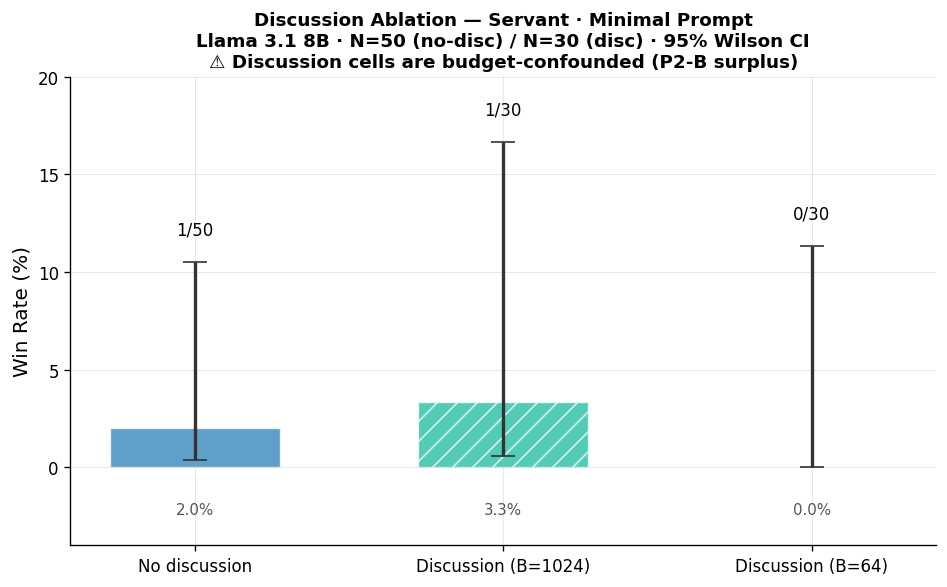

Saved: fig_e1_discussion_ablation.png


In [7]:

# ── Figure 4: Discussion ablation (Servant, minimal prompt) ───────────────────
# Comparing: no-disc B=1024 | disc B=1024 | disc B=64
# Note: disc cells are budget-confounded — discussion call consumes the full B
# budget before the vote call. See avalon_plan.md §P2-B.

servant_min = trials_df[
    (trials_df['llm_role'] == 'Servant') &
    (trials_df['prompt_variant'] == 'minimal')
].copy()

disc_conditions = [
    ('No discussion', False, 1024, '#2980b9', ''),
    ('Discussion (B=1024)', True, 1024, '#1abc9c', DISC_HATCH),
    ('Discussion (B=64)',  True,  64,  '#f39c12', DISC_HATCH),
]

fig, ax = plt.subplots(figsize=(8, 5))

for i, (label, disc, budget, color, hatch) in enumerate(disc_conditions):
    sub = servant_min[
        (servant_min['with_discussion'] == disc) &
        (servant_min['budget'] == budget)
    ]
    n    = len(sub)
    wins = int(sub['llm_win'].sum())
    p, lo, hi = wilson_ci(wins, n)
    lo_err = max(0.0, (p - lo) * 100)
    hi_err = max(0.0, (hi - p) * 100)
    p_pct  = p * 100

    ax.bar(i, p_pct, 0.55, color=color, alpha=0.75, hatch=hatch,
           edgecolor='white', linewidth=0.8, label=label)
    ax.errorbar(i, p_pct, yerr=[[lo_err], [hi_err]],
                fmt='none', color='#333', elinewidth=2, capsize=7, zorder=5)
    ax.text(i, hi * 100 + 1.2, f"{wins}/{n}", ha='center', va='bottom', fontsize=10)
    ax.text(i, -1.8, f"{p_pct:.1f}%", ha='center', va='top', fontsize=9, color='#555')

ax.set_xticks(range(len(disc_conditions)))
ax.set_xticklabels([c[0] for c in disc_conditions], fontsize=10)
ax.set_ylim(-4, 20)
ax.set_ylabel('Win Rate (%)', fontsize=12)
ax.set_title('Discussion Ablation — Servant · Minimal Prompt\n'
             'Llama 3.1 8B · N=50 (no-disc) / N=30 (disc) · 95% Wilson CI\n'
             '⚠ Discussion cells are budget-confounded (P2-B surplus)',
             fontsize=11, fontweight='bold')

# Merlin disc reference numbers
merlin_min = trials_df[
    (trials_df['llm_role'] == 'Merlin') &
    (trials_df['prompt_variant'] == 'minimal')
]
m_no_disc = merlin_min[~merlin_min['with_discussion']]
m_disc    = merlin_min[merlin_min['with_discussion']]
print(f"Merlin no-disc:  {int(m_no_disc['llm_win'].sum())}/{len(m_no_disc)} wins")
print(f"Merlin disc:     {int(m_disc['llm_win'].sum())}/{len(m_disc)} wins")

plt.tight_layout()
plt.savefig('fig_e1_discussion_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_discussion_ablation.png')


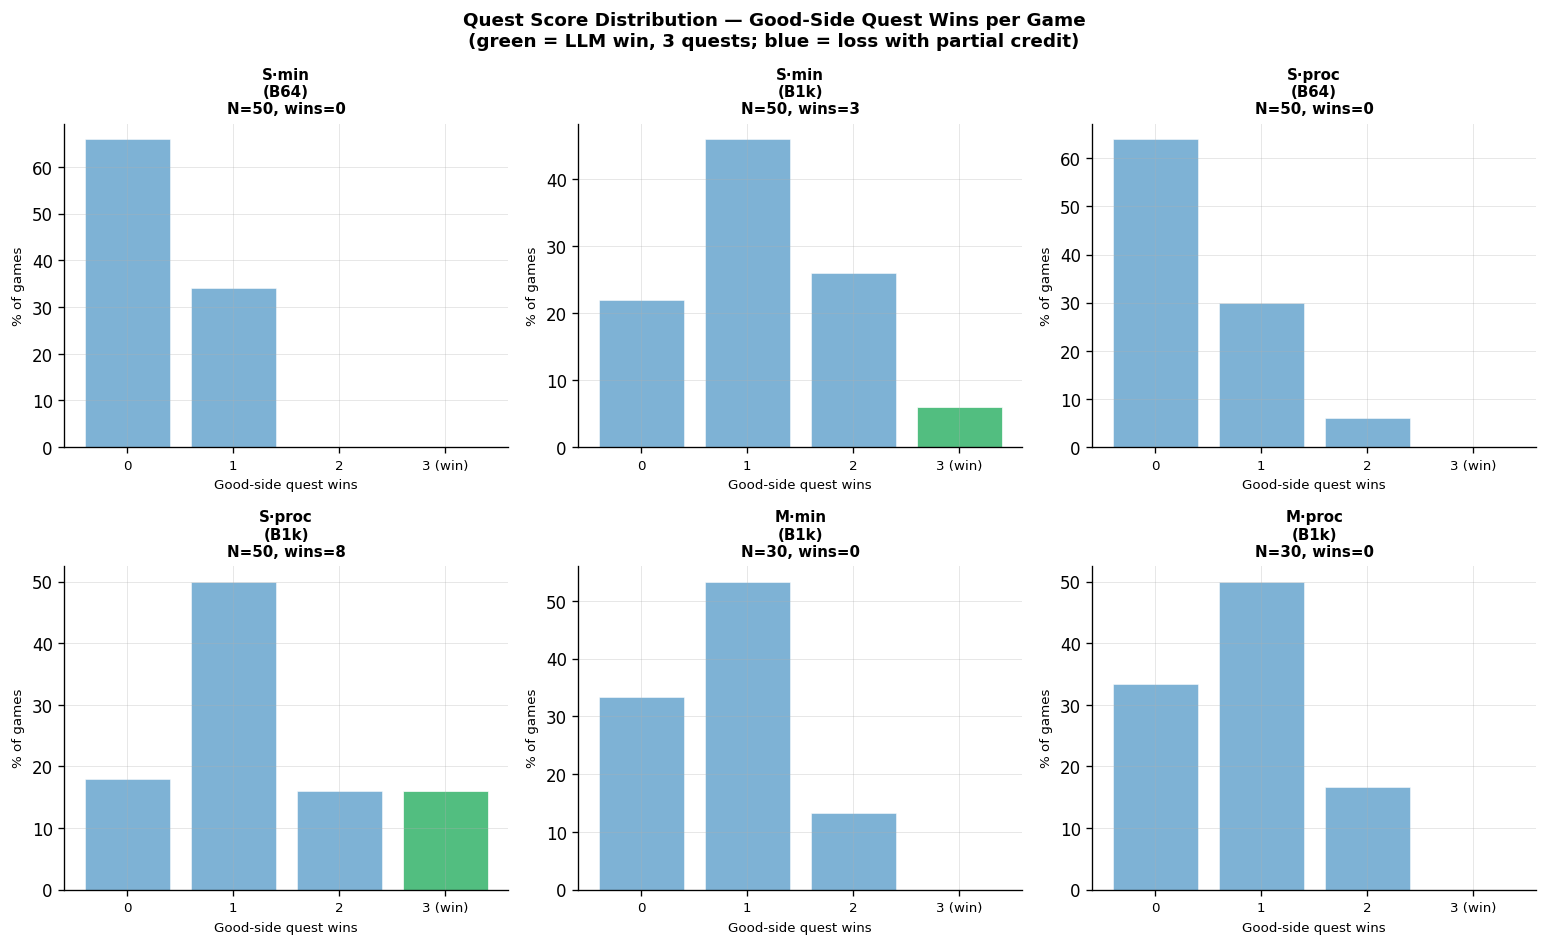

Saved: fig_e1_quest_scores.png


In [8]:
# ── Figure 5: Quest score distributions ───────────────────────────────────────
# final_score_llm = quests won by good side (LLM is always good side)
# final_score_uct = quests won by evil side
# Game ends when one side reaches 3 quest wins.

no_disc = trials_df[~trials_df['with_discussion']].copy()

# Group into 4 primary conditions for comparison
conditions_scores = {
    'S·min\n(B64)':   no_disc[(no_disc['llm_role']=='Servant') & (no_disc['prompt_variant']=='minimal') & (no_disc['budget']==64)],
    'S·min\n(B1k)':   no_disc[(no_disc['llm_role']=='Servant') & (no_disc['prompt_variant']=='minimal') & (no_disc['budget']==1024)],
    'S·proc\n(B64)':  no_disc[(no_disc['llm_role']=='Servant') & (no_disc['prompt_variant']=='procedural') & (no_disc['budget']==64)],
    'S·proc\n(B1k)':  no_disc[(no_disc['llm_role']=='Servant') & (no_disc['prompt_variant']=='procedural') & (no_disc['budget']==1024)],
    'M·min\n(B1k)':   no_disc[(no_disc['llm_role']=='Merlin')  & (no_disc['prompt_variant']=='minimal') & (no_disc['budget']==1024)],
    'M·proc\n(B1k)':  no_disc[(no_disc['llm_role']=='Merlin')  & (no_disc['prompt_variant']=='procedural') & (no_disc['budget']==1024)],
}

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharey=False)
axes_flat = axes.flatten()

for ax, (label, sub) in zip(axes_flat, conditions_scores.items()):
    # Quest scores for good side (LLM) and evil side
    good_scores = sub['final_score_llm'].dropna().astype(int)
    evil_scores = sub['final_score_uct'].dropna().astype(int)
    all_scores  = pd.concat([good_scores.rename('good'), evil_scores.rename('evil')], axis=1).dropna()

    # Distribution of good-side quest wins (0, 1, 2 — they rarely win so max is 2 in losses, 3 in wins)
    for score_val in range(4):
        count = (all_scores['good'] == score_val).sum()
        is_win = score_val == 3
        color = '#27ae60' if is_win else '#2980b9'
        ax.bar(score_val, count / len(all_scores) * 100,
               color=color, alpha=0.8 if is_win else 0.6,
               edgecolor='white', linewidth=0.5)

    n = len(all_scores)
    wins = int((all_scores['good'] == 3).sum())
    ax.set_title(f'{label}\nN={n}, wins={wins}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Good-side quest wins', fontsize=8)
    ax.set_ylabel('% of games', fontsize=8)
    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(['0', '1', '2', '3 (win)'], fontsize=8)

fig.suptitle('Quest Score Distribution — Good-Side Quest Wins per Game\n'
             '(green = LLM win, 3 quests; blue = loss with partial credit)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_e1_quest_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_quest_scores.png')

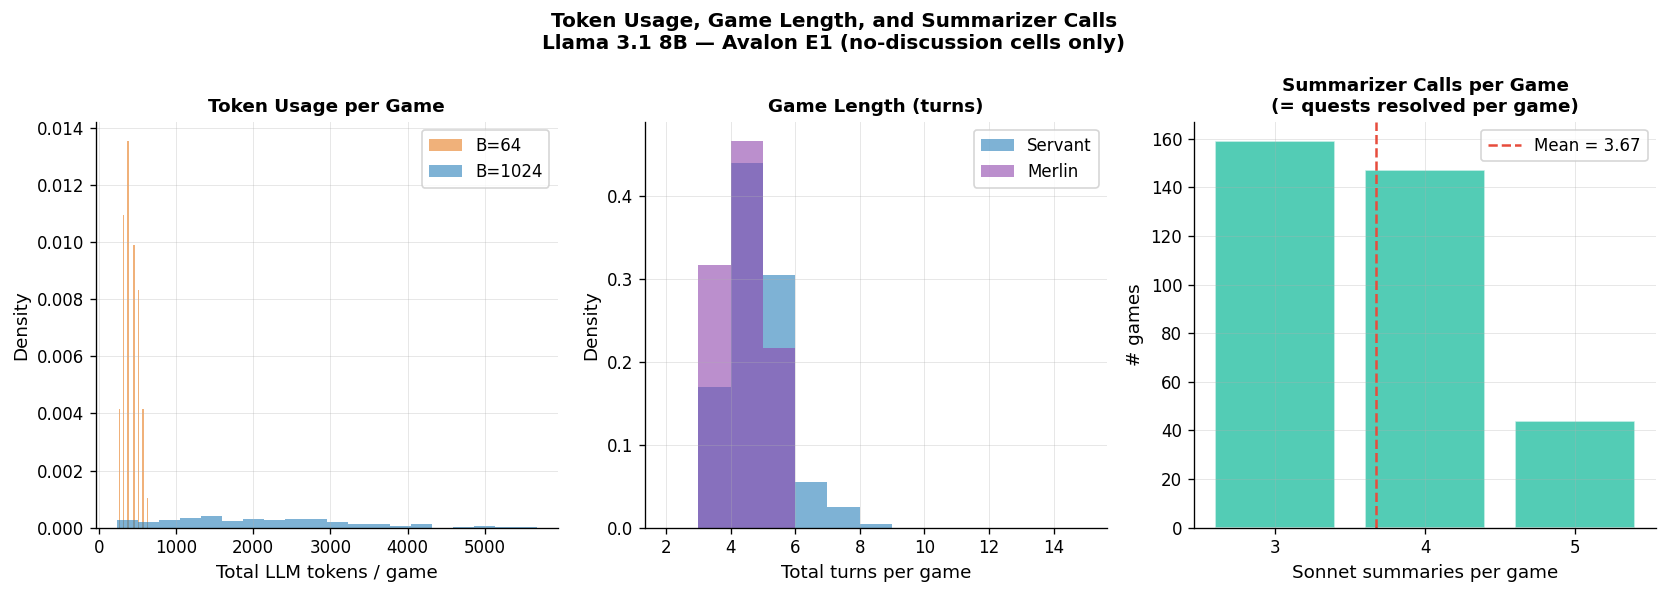

Saved: fig_e1_diagnostics.png
B=64: mean tokens/game = 413 (expected ~413 at cap)
B=1024: mean tokens/game = 2066 (expected ~7174 at cap)


In [9]:
# ── Figure 6: Token usage and game length ─────────────────────────────────────

no_disc = trials_df[~trials_df['with_discussion']].copy()
no_disc['tokens_per_llm_turn'] = no_disc['n_tokens_llm_total'] / no_disc['n_llm_turns'].replace(0, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Panel 1: Total tokens per game by budget
ax = axes[0]
for budget, color in [(64, '#e67e22'), (1024, '#2980b9')]:
    sub = no_disc[no_disc['budget'] == budget]
    ax.hist(sub['n_tokens_llm_total'].dropna(), bins=20, color=color, alpha=0.6,
            label=f'B={budget}', density=True)
ax.set_xlabel('Total LLM tokens / game', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Token Usage per Game', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

# Panel 2: Game length (turns) by role
ax = axes[1]
for role, color in [('Servant', '#2980b9'), ('Merlin', '#8e44ad')]:
    sub = no_disc[no_disc['llm_role'] == role]
    ax.hist(sub['n_turns_total'].dropna(), bins=range(2, 16), color=color, alpha=0.6,
            label=role, density=True)
ax.set_xlabel('Total turns per game', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Game Length (turns)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

# Panel 3: Summaries per game
ax = axes[2]
summ_per_game = summaries_df.groupby('trial_id').size().reset_index(name='n_summaries')
summ_with_run = summaries_df[['trial_id', 'run_name']].drop_duplicates().merge(summ_per_game, on='trial_id')
# Just show distribution
counts = summ_per_game['n_summaries'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color='#1abc9c', alpha=0.75, edgecolor='white')
ax.set_xlabel('Sonnet summaries per game', fontsize=11)
ax.set_ylabel('# games', fontsize=11)
ax.set_title('Summarizer Calls per Game\n(= quests resolved per game)', fontsize=11, fontweight='bold')
ax.set_xticks(counts.index)

mean_s = summ_per_game['n_summaries'].mean()
ax.axvline(mean_s, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Mean = {mean_s:.2f}')
ax.legend(fontsize=10)

fig.suptitle('Token Usage, Game Length, and Summarizer Calls\nLlama 3.1 8B — Avalon E1 (no-discussion cells only)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_e1_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_diagnostics.png')

# Print summary stats
for budget in [64, 1024]:
    sub = no_disc[no_disc['budget'] == budget]
    print(f"B={budget}: mean tokens/game = {sub['n_tokens_llm_total'].mean():.0f} "
          f"(expected ~{budget * sub['n_llm_turns'].mean():.0f} at cap)")

In [10]:
# ── Sample summaries (qualitative) ────────────────────────────────────────────

print('=== Sample Sonnet Summaries (AvalonSummarizer) ===\n')

# Pick 3 summaries from different runs
sample_runs = ['avalon_e1_servant_minimal', 'avalon_e1_servant_procedural', 'avalon_e1_merlin']

for run_name in sample_runs:
    sample = summaries_df[summaries_df['run_name'] == run_name].head(1)
    if sample.empty:
        continue
    row = sample.iloc[0]
    print(f'--- Run: {run_name} | trial_id: {row["trial_id"][:12]}... | '
          f'after_turn={row["after_turn_idx"]} | est_tokens={row["n_tokens_est"]} ---')
    print(row['summary_text'])
    print()

=== Sample Sonnet Summaries (AvalonSummarizer) ===

--- Run: avalon_e1_servant_minimal | trial_id: trial_6a6612... | after_turn=0 | est_tokens=163 ---
== QUEST LOG ==
Q1: FAIL | Team: [2, 3] | Fail-vote count: 1

== VOTE RECORD ==
Q1 attempt 1: Leader=P2 proposed [2, 3] | approve: [P0, P2, P3, P4] | reject: [P1] | ACCEPTED

== TEAM STATS ==
Players on 1+ failed quests: P2, P3
Players never on any quest team yet: P0, P1, P4
Tracked player (P0) quest appearances: none

== SCORE ==
Good wins: 0 | Evil wins: 1 | Quests remaining: 4

--- Run: avalon_e1_servant_procedural | trial_id: trial_afa07d... | after_turn=0 | est_tokens=163 ---
== QUEST LOG ==
Q1: FAIL | Team: [2, 3] | Fail-vote count: 1

== VOTE RECORD ==
Q1 attempt 1: Leader=P2 proposed [2, 3] | approve: [P2, P3, P4] | reject: [P0, P1] | ACCEPTED

== TEAM STATS ==
Players on 1+ failed quests: P2, P3
Players never on any quest team yet: P0, P1, P4
Tracked player (P0) quest appearances: none

== SCORE ==
Good wins: 0 | Evil wins: 1 | 

In [11]:
# ── Master summary table ───────────────────────────────────────────────────────

print('=== Avalon E1 — Full Results Table ===')
print(f'{"Condition":<28} {"B":>5} {"Disc":>4} {"N":>4} {"Wins":>5}  {"Win%":>6}  {"95% CI":^18}  {"summ/g":>7}')
print('-' * 88)

condition_order = [
    ('Servant·minimal',    'Servant', 'minimal',    False),
    ('Servant·procedural', 'Servant', 'procedural', False),
    ('Merlin·minimal',     'Merlin',  'minimal',    False),
    ('Merlin·procedural',  'Merlin',  'procedural', False),
    ('S·min·disc',         'Servant', 'minimal',    True),
    ('M·min·disc',         'Merlin',  'minimal',    True),
]

# Compute summaries per game per condition
trial_summ_count = summaries_df.groupby('trial_id').size().reset_index(name='n_summ')
trials_with_summ = trials_df.merge(trial_summ_count, on='trial_id', how='left')
trials_with_summ['n_summ'] = trials_with_summ['n_summ'].fillna(0)

def _print_condition(cond_label, sub_all, sub_summ, disc=False):
    for budget in sorted(sub_all['budget'].unique()):
        cell   = sub_all[sub_all['budget'] == budget]
        cell_s = sub_summ[sub_summ['budget'] == budget]
        n      = len(cell)
        wins   = int(cell['llm_win'].sum())
        p, lo, hi = wilson_ci(wins, n)
        spg    = cell_s['n_summ'].mean() if len(cell_s) > 0 else float('nan')
        disc_str = 'Y' if disc else '-'
        ci_str   = f"[{lo*100:.1f}%, {hi*100:.1f}%]"
        print(f"{cond_label:<28} {budget:>5} {disc_str:>4} {n:>4} {wins:>5}  "
              f"{p*100:>5.1f}%  {ci_str:^18}  {spg:>7.2f}")

for cond_label, role, variant, disc in condition_order:
    sub_all = trials_df[
        (trials_df['llm_role'] == role) &
        (trials_df['prompt_variant'] == variant) &
        (trials_df['with_discussion'] == disc)
    ]
    sub_summ = trials_with_summ[
        (trials_with_summ['llm_role'] == role) &
        (trials_with_summ['prompt_variant'] == variant) &
        (trials_with_summ['with_discussion'] == disc)
    ]
    _print_condition(cond_label, sub_all, sub_summ, disc=disc)

# ── llamasumm row (loaded separately from SQLite) ─────────────────────────────
print()
print('--- Llama-as-summarizer ablation ---')
conn2 = sqlite3.connect(DB_PATH)
ls_trials = pd.read_sql_query("""
    SELECT t.trial_id, t.condition_json, t.winner
    FROM runs r
    JOIN trials t ON t.run_id = r.run_id
    WHERE r.name LIKE 'avalon_e1_servant_llamasumm%'
      AND r.name NOT LIKE 'smoke%'
""", conn2)
ls_summ_count = pd.read_sql_query("""
    SELECT t.trial_id, COUNT(s.summary_id) AS n_summ
    FROM runs r
    JOIN trials t ON t.run_id = r.run_id
    JOIN summaries s ON s.trial_id = t.trial_id
    WHERE r.name LIKE 'avalon_e1_servant_llamasumm%'
    GROUP BY t.trial_id
""", conn2)
conn2.close()

if not ls_trials.empty:
    cond_ls = ls_trials['condition_json'].apply(json.loads)
    ls_trials['budget']  = cond_ls.apply(lambda c: c['budget'])
    ls_trials['llm_win'] = (ls_trials['winner'] == 'llm').astype(int)
    ls_trials['n_summ']  = ls_trials['trial_id'].map(
        ls_summ_count.set_index('trial_id')['n_summ']
    ).fillna(0)
    for budget in sorted(ls_trials['budget'].unique()):
        cell  = ls_trials[ls_trials['budget'] == budget]
        n     = len(cell)
        wins  = int(cell['llm_win'].sum())
        p, lo, hi = wilson_ci(wins, n)
        spg   = cell['n_summ'].mean()
        ci_str = f"[{lo*100:.1f}%, {hi*100:.1f}%]"
        print(f"{'S·min·llamasumm':<28} {budget:>5} {'-':>4} {n:>4} {wins:>5}  "
              f"{p*100:>5.1f}%  {ci_str:^18}  {spg:>7.2f}")
else:
    print('  (llamasumm sweep not yet complete)')

print()
print('Primary runs: 7 runs, 350 trials, 0 errors. llamasumm is the ablation.')
print('Disc cells (P2-B) are budget-confounded — exclude from primary budget comparisons.')

=== Avalon E1 — Full Results Table ===
Condition                        B Disc    N  Wins    Win%        95% CI         summ/g
----------------------------------------------------------------------------------------
Servant·minimal                 64    -   50     0    0.0%     [0.0%, 7.1%]        3.34
Servant·minimal               1024    -   50     1    2.0%    [0.4%, 10.5%]        4.10
Servant·procedural              64    -   50     0    0.0%     [0.0%, 7.1%]        3.42
Servant·procedural            1024    -   50     4    8.0%    [3.2%, 18.8%]        4.06
Merlin·minimal                1024    -   30     0    0.0%    [0.0%, 11.4%]        3.80
Merlin·procedural             1024    -   30     0    0.0%    [0.0%, 11.4%]        3.83
S·min·disc                      64    Y   30     0    0.0%    [0.0%, 11.4%]        3.23
S·min·disc                    1024    Y   30     1    3.3%    [0.6%, 16.7%]        3.57
M·min·disc                    1024    Y   30     0    0.0%    [0.0%, 11.4%]     

## Interpretation

### Bot strategy (not random — structured rule-based)
The four non-LLM players use fixed deterministic strategies matching the AvalonBench naive baseline
(Light et al., NeurIPS 2023):

| Role | Team proposal | Team vote | Quest vote |
|------|--------------|-----------|------------|
| Bot Merlin | Proposes from good players only | Reject if team contains evil; approve otherwise | Pass |
| Bot Servant | Uniformly random | **Always approve** | Pass |
| Evil bots | Always include ≥1 evil | Approve if team has evil; reject otherwise | Fail |
| Assassin | — | (as evil) | Fail; random Merlin guess at end |

### Structural vote-blocking constraint
In the 5-player configuration (LLM + Bot Merlin + Bot Servant vs. Evil1 + Evil2), any evil-containing
team proposal receives at least **3 unconditional approvals** (Evil1 + Evil2 + Bot Servant), giving
it a majority before the LLM votes. This means:

> **The LLM's team vote is structurally irrelevant — it can never change whether an evil team goes on a quest.**

The LLM's only effective lever is its **team proposals when it is the leader**. If LLM proposes a
clean good-only team, Bot Merlin + Bot Servant + LLM = 3 approvals → team passes. If LLM proposes
an evil-containing team, the quest fails (evil bots on the quest vote to fail).

This partially weakens the result: the low win rates are not purely a measure of LLM reasoning
quality — they are also a consequence of structural asymmetry where the good side cannot veto
evil proposals regardless of how well the LLM reasons. The experiment measures something closer to
"does the LLM propose good teams when it's leader?" rather than "can the LLM identify and reject
evil players across votes?"

The comparison remains internally valid (all cells face the same setup), and the bot strategies
match the AvalonBench paper's naive baseline, making cross-paper comparisons meaningful. But the
interpretation of absolute win rates should account for this structural ceiling.

### Overall win rates
Llama 3.1 8B wins rarely across all conditions (0–8%). Contributing factors:
1. Vote irrelevance: LLM's team-vote decisions cannot change quest outcomes (see above)
2. Leader frequency: LLM is P0, leading in ~15–17% of quest slots (below the 20% uniform baseline)
3. Merlin 0%: Merlin cannot block evil proposals despite full evil knowledge; no games reached the
   assassination phase (evil wins 3 quests in every observed Merlin game, confirmed by trace review)

### Budget effect (B=64 vs B=1024, Servant)
- **Minimal prompt**: 0% → 2% (1/50 at B=1024) — within noise
- **Procedural prompt**: 0% → 8% (4/50 at B=1024) — directionally consistent with the CoT budget hypothesis

Neither effect is significant at N=50, but the procedural direction is the strongest signal.

### B=64 incoherence: proposal quality vs voting behavior
At B=64, there is a striking incoherence between the LLM's two separate decision calls:

- **Unconditional quality** (what the LLM proposes as leader): 42–46% clean proposals at B=64,
  **above the random-team baseline of ~20%** — the model still prefers good players even at B=64.
- **Conditional quality** (what makes it through to a quest): ~23% at B=64, near the random baseline.

The divergence (uncond ≈ 46% >> cond ≈ 23%) is explained by how the vote filter interacts with
bot voting rules:
- **Dirty proposals**: always accepted (Evil1 + Evil2 + Bot Servant = 3 unconditional approvals)
- **Clean proposals**: pass 5-to-0 if LLM approves, fail 3-to-2 if LLM **rejects its own proposal**

At B=64, the data is consistent with the LLM frequently rejecting its own clean-team proposals as a
voter — the separate team-vote call, also truncated to 64 tokens, produces inconsistent decisions.
Result: accepted quests are dominated by dirty teams, driving conditional quality near random even
though unconditional quality is above random.

> **B=64 finding**: The model's *proposal* quality is above random at B=64, but its *voting* behavior
> is incoherent with its proposals. Conditional quality (~23%) is misleadingly low because the vote
> filter selects against the LLM's own clean proposals. Unconditional quality (42–46%) is the more
> faithful signal at this budget level.

Prompt variant has no measurable effect at B=64 (uncond: 45.9% minimal vs 42.1% procedural — within
noise). Prompt design only matters at sufficient budget.

### Prompt variant (minimal vs procedural, B=1024)
- **Servant**: minimal 61% vs procedural 91% conditional quality, 65% vs 93% unconditional quality
- **Merlin**: minimal 94% vs procedural 95% — both near ceiling

**P0 self-inclusion confound**: The procedural prompt explicitly instructs "include yourself when
possible as a tie-break." Since P0 (the LLM) is always a good-side player, self-inclusion mechanically
raises team cleanliness regardless of whether the model is doing correct Bayesian reasoning. From the
diagnostics (Fig 9, P0 self-inclusion panel):
- S·proc·B64: P0 included in ~40% of proposals
- S·proc·B1k: P0 included in ~98% of proposals

The 98% P0 self-inclusion at B=1024 accounts for much of the procedural vs minimal quality gap. The
cleaner measure is **unconditional quality** (Fig 9, panel c), which confirms a real difference (65%
vs 93%) but attenuated relative to the conditional metric. The "include yourself" tie-break is a
significant confound for the "Bayesian update helps" interpretation.

### Proposal quality decomposition (selection effect)
Fig 9 shows four metrics for each primary condition:
- **Acceptance rate** varies by condition (S·min·B64 ~70%, S·proc·B1k ~78%) — the selection filter
  is not uniform, so conditional quality is contaminated by which proposals survive to become quests
- **Unconditional quality** = P(proposed team is clean | LLM proposed, regardless of acceptance) is
  the cleanest measure: it bypasses bot voting dynamics and the B=64 incoherence described above
- The B=64 unconditional quality is above random baseline but well below B=1024, confirming a real
  budget effect on team selection ability even when controlling for voting incoherence
- The P0 self-inclusion confound is the main driver of the minimal vs procedural gap at B=1024

### Discussion ablation (P2-B, qualitative)
Budget-confounded (discussion consumes the full B budget before vote). With that caveat:
- Servant + discussion B=1024: 3.3% (1/30) — within noise of no-discussion
- Discussion does not appear to help substantially at N=30

### Merlin failure mode
All 90 Merlin games (across minimal, procedural, and disc conditions) ended with evil winning 3
quests — no game reached the assassination phase. The Merlin trace review (`scripts/review_merlin_traces.py`)
shows the dominant failure mode: evil players hold the proposal slot in the first few quests and
pass evil-containing teams with majority bot approval before Merlin has enough leader turns to build
a good-quest advantage. This is purely a structural constraint, not a reasoning failure.

### Next steps
1. **Unconditional quality is the primary metric**: Conditional quality (cond_qual) is biased by both
   the vote-blocking selection effect and the B=64 incoherence. Unconditional quality should be
   reported as the headline number.
2. **L-S-llamasumm**: Run Llama-as-summarizer ablation to isolate summarizer model effect
3. **Larger models**: Qwen or Llama 70B to establish an upper-bound win rate under the same structural constraint
4. **Increase N**: N=50 is underpowered at 2–8% win rates; N=100+ recommended for primary comparisons


---

## Study Limitation: Fixed Role Positions (Evil Pinned to P3/P4)

### The issue

In `make_env_from_seed`, non-LLM roles are assigned as:

```python
# Default behaviour (shuffle_all_roles=False)
other_good = rng.permutation(remaining_good).tolist()   # shuffles Good bots among P1–P2
evil       = rng.permutation(["Minion", "Assassin"]).tolist()  # shuffles Evil bots among P3–P4
role_names = [llm_role] + other_good + evil
```

The two Evil players (Minion and Assassin) shuffle their identities between positions P3 and P4, but they **never appear at P1 or P2**. Every seed in every E1 run has this structure.

This degenerates the Bayesian update problem for a Servant:

- After one failed quest, a rational agent knows to suspect P3 and P4 specifically — not from accumulated quest evidence but from the fixed position prior.
- After two failed quests, near-certainty about P3 and P4 follows from position structure alone, regardless of who voted how or who was on each quest.
- The model can achieve high unconditional proposal quality simply by learning the static heuristic "never include P3 or P4" — without performing any genuine belief updating from quest outcomes.

The high uncond_qual at B=1024 with the procedural prompt (92.5% Servant, 94.7% Merlin) is therefore partially ambiguous: it is consistent with genuine Bayesian reasoning **and** with exploitation of the structural position prior. The two cannot be separated from these data.

Merlin is less affected — Merlin legitimately knows identities at game start, so its near-zero regret (5.3%) reflects real information use. Servant results carry the confound.

### The proposed fix — `shuffle_all_roles=True`

The flag `shuffle_all_roles=True` in `AvalonSweepConfig` changes the assignment to:

```python
# shuffle_all_roles=True
non_llm    = rng.permutation(remaining_good + ["Minion", "Assassin"]).tolist()
role_names = [llm_role] + non_llm
```

Evil can now appear at any of P1–P4. The position prior collapses to uniform: the model must reason from quest outcomes and vote patterns, making the Bayesian update genuinely non-trivial. Proposal quality at B=1024 is expected to be lower than in E1 (the task is harder), but the measurement becomes methodologically honest.

### Status

Intermediate-budget sweep configs (`avalon_e1_servant_b128/b256/b512_n30.yaml`) were built with `shuffle_all_roles: true` and launched. All trials errored because the Sonnet summarizer requires an Anthropic API key that is not set in the SGLang-only GPU environment.

**Fix (one line per config):**
```yaml
summarizer_backend: sglang        # use local Llama 8B instead of Sonnet
summarizer_base_url: http://localhost:30000
```

The llamasumm ablation (Experiment A6) already confirms Llama 8B and Sonnet produce statistically equivalent summaries, so this substitution is methodologically clean.

The existing E1 results remain valid as the **fixed-position** condition and will be reported as such. The shuffled condition is a planned follow-up experiment.

---
## Leader-Turn Proposal Quality
*Re-aggregating by the LLM's actual lever: team proposals when it is the leader.*

Because bot Servant always approves, the LLM's **team vote** cannot change outcomes (evil proposals
always pass 3–2 regardless of LLM's vote). The LLM's only lever is its **team proposal when it is
the leader**. The metric below isolates that lever:

> **Proposal quality** = P(quest succeeded | LLM proposed the accepted team)

Since evil bots always fail quests they're on, this equals P(LLM proposed a team with no evil
members). A budget effect here means the LLM is choosing cleaner teams as reasoning budget grows —
even if that signal doesn't survive aggregation to the win-rate level.


In [12]:

# ── Parse JSONL: LLM leader-turn proposals (corrected) ────────────────────────
# Corrected: match proposals to vote results by (quest_turn, round), not by
# team composition. Records team cleanliness (from game_start.role_names) and
# P0 self-inclusion for ALL proposals; quest outcome for accepted ones only.

import json
from pathlib import Path

RUNS_DIR = ROOT / 'data' / 'runs'

VALID_RUN_DIRS = [d for d in RUNS_DIR.iterdir()
                  if d.is_dir() and not d.name.startswith('_')
                  and any(d.name.startswith(prefix) for prefix in [
                      # E1 original (fixed-pos, naive bots)
                      'avalon_e1_servant_minimal__',
                      'avalon_e1_servant_procedural__',
                      'avalon_e1_merlin__',
                      'avalon_e1_merlin_procedural__',
                      'avalon_e1_servant_minimal_disc__',
                      'avalon_e1_servant_minimal_disc_low__',
                      'avalon_e1_merlin_minimal_disc__',
                      # E1 shuffled (fix for evil-position pinning, naive bots)
                      'avalon_e1_servant_proc_bayesian__',
                      'avalon_e1_merlin_min_bayesian__',
                      'avalon_e1_merlin_proc_bayesian__',
                      # E2 (shuffled + Bayesian Servant bots, matches AvalonBench)
                      'avalon_e2_servant_min_b64_bayesian__',
                      'avalon_e2_servant_min_b128_bayesian__',
                      'avalon_e2_servant_min_b256_bayesian__',
                      'avalon_e2_servant_min_b512_bayesian__',
                      'avalon_e2_servant_min_b1024_bayesian__',
                  ])]

print(f"Found {len(VALID_RUN_DIRS)} valid run directories:")
for d in sorted(VALID_RUN_DIRS):
    print(f"  {d.name}")

proposal_records = []

for run_dir in sorted(VALID_RUN_DIRS):
    run_name = run_dir.name.split('__')[0]
    for fpath in sorted(run_dir.glob('trial_*.jsonl')):
        lines = fpath.read_text().splitlines()
        if not lines:
            continue
        events = [json.loads(l) for l in lines if l.strip()]

        start = next((e for e in events if e['event'] == 'trial_start'), None)
        if not start:
            continue
        cond = start['condition']

        # Identify evil players from game_start role_names
        gs = next((e for e in events if e['event'] == 'game_start'), None)
        if not gs:
            continue
        evil_players = frozenset(
            i for i, r in enumerate(gs['role_names']) if r in ('Assassin', 'Minion')
        )

        # Index team_vote_result by (quest_turn, round) for correct acceptance lookup
        vote_by_round = {}
        for ev in events:
            if ev['event'] == 'team_vote_result':
                vote_by_round[(ev['quest_turn'], ev['round'])] = ev

        # Index quest outcomes by quest_turn
        quest_outcomes = {}
        for ev in events:
            if ev['event'] == 'quest_result':
                quest_outcomes[ev['quest_turn']] = ev

        for ev in events:
            if ev['event'] == 'team_proposed' and ev.get('is_llm_decision'):
                qt   = ev['quest_turn']
                rnd  = ev['round']
                team = frozenset(ev['team'])

                vote     = vote_by_round.get((qt, rnd))
                accepted = bool(vote and vote.get('accepted', False))

                q_ev      = quest_outcomes.get(qt) if accepted else None
                succeeded = q_ev['succeeded'] if q_ev else None

                proposal_records.append({
                    'run_name':        run_name,
                    'budget':          cond['budget'],
                    'llm_role':        cond['llm_role'],
                    'prompt_variant':  cond['prompt_variant'],
                    'with_discussion': cond.get('with_discussion', False),
                    'seed':            cond['seed'],
                    'quest_turn':      qt,
                    'round':           rnd,
                    'team_size':       len(team),
                    'accepted':        accepted,
                    'team_is_clean':   len(team & evil_players) == 0,
                    'includes_p0':     0 in team,
                    'succeeded':       succeeded,
                })

prop_df = pd.DataFrame(proposal_records)
accepted_df = prop_df[prop_df['accepted']].copy()

print(f"\nTotal LLM leader proposals: {len(prop_df)}")
print(f"Accepted (proposal went to quest): {len(accepted_df)}")
print(f"Rejected (proposal voted down):    {len(prop_df) - len(accepted_df)}")

# Per-condition summary: rejection rate, unconditional quality, conditional quality, P0 inclusion
_grp = ['llm_role', 'prompt_variant', 'with_discussion', 'budget']
_s = prop_df.groupby(_grp).agg(
    n_props=('accepted', 'count'),
    n_acc=('accepted', 'sum'),
    n_clean=('team_is_clean', 'sum'),
    n_p0=('includes_p0', 'sum'),
).reset_index()
_s['rej_rate']    = 1 - _s['n_acc'] / _s['n_props']
_s['uncond_qual'] = _s['n_clean'] / _s['n_props']
_s['p0_inc']      = _s['n_p0'] / _s['n_props']
_a = accepted_df.groupby(_grp).agg(n_a=('succeeded', 'count'), n_s=('succeeded', 'sum')).reset_index()
_a['cond_qual'] = _a['n_s'] / _a['n_a']
_full = _s.merge(_a, on=_grp, how='left')
print('\nPer-condition diagnostics:')
print(_full[_grp + ['n_props', 'rej_rate', 'uncond_qual', 'cond_qual', 'p0_inc']].round(3).to_string(index=False))


Found 7 valid run directories:
  avalon_e1_merlin__e5611409
  avalon_e1_merlin_minimal_disc__e4fbe6d9
  avalon_e1_merlin_procedural__bddd624b
  avalon_e1_servant_minimal__3032219a
  avalon_e1_servant_minimal_disc__663e6786
  avalon_e1_servant_minimal_disc_low__f380a740
  avalon_e1_servant_procedural__882a1d16

Total LLM leader proposals: 254
Accepted (proposal went to quest): 211
Rejected (proposal voted down):    43

Per-condition diagnostics:
llm_role prompt_variant  with_discussion  budget  n_props  rej_rate  uncond_qual cond_qual  p0_inc
  Merlin        minimal            False    1024       19     0.053        0.947  0.944444   0.789
  Merlin        minimal             True    1024       19     0.105        0.842  0.764706   0.737
  Merlin     procedural            False    1024       19     0.000        0.947  0.947368   1.000
 Servant        minimal            False      64       37     0.297        0.459  0.230769   0.730
 Servant        minimal            False    1024       3

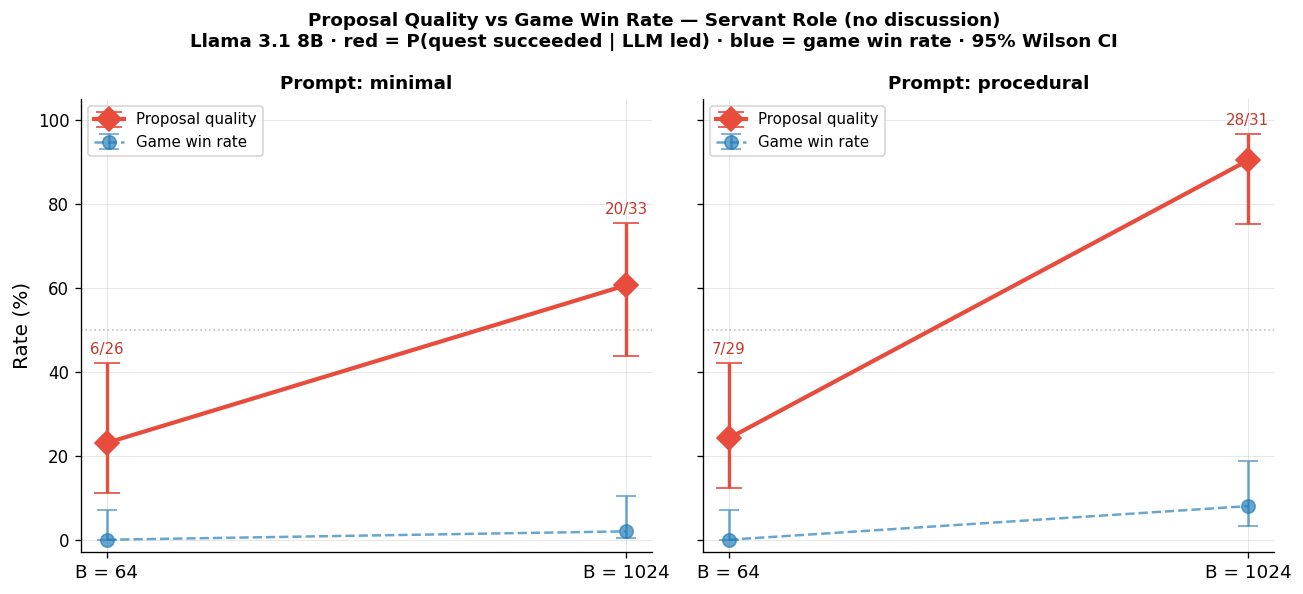

Saved: fig_e1_proposal_quality.png

Proposal quality (red) vs game win rate (blue):

  minimal:
    B=64     proposal_q=23.1%  (6/26 quests)  |  win_rate=0.0%  (0/50 games)
    B=1024   proposal_q=60.6%  (20/33 quests)  |  win_rate=2.0%  (1/50 games)

  procedural:
    B=64     proposal_q=24.1%  (7/29 quests)  |  win_rate=0.0%  (0/50 games)
    B=1024   proposal_q=90.3%  (28/31 quests)  |  win_rate=8.0%  (4/50 games)


In [13]:

# ── Figure 7: Proposal quality vs budget (Servant, primary conditions) ─────────

servant_acc = accepted_df[
    (accepted_df['llm_role'] == 'Servant') &
    (~accepted_df['with_discussion'])
].copy()

prop_wr = win_rate_table(servant_acc.rename(columns={'succeeded': 'llm_win'}),
                         ['prompt_variant', 'budget'])

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, variant in zip(axes, ['minimal', 'procedural']):
    sub = prop_wr[prop_wr['prompt_variant'] == variant].sort_values('budget')
    wrs = sub['win_rate'].tolist()
    ns  = sub['n'].tolist()
    los = sub['ci_lo'].tolist()
    his = sub['ci_hi'].tolist()
    wins_list = sub['wins'].tolist()

    ax.errorbar(
        [0, 1], [w * 100 for w in wrs],
        yerr=_errbars(wrs, los, his),
        fmt='D-', color='#e74c3c', ecolor='#e74c3c',
        elinewidth=2, capsize=8, markersize=10, linewidth=2.5, zorder=5,
        label='Proposal quality'
    )

    # Overlay win rate from Fig 2 for reference
    wr_sub = wr_servant[wr_servant['prompt_variant'] == variant].sort_values('budget')
    wrs_wr = wr_sub['win_rate'].tolist()
    los_wr = wr_sub['ci_lo'].tolist()
    his_wr = wr_sub['ci_hi'].tolist()
    ax.errorbar(
        [0, 1], [w * 100 for w in wrs_wr],
        yerr=_errbars(wrs_wr, los_wr, his_wr),
        fmt='o--', color='#2980b9', ecolor='#2980b9',
        elinewidth=1.5, capsize=6, markersize=8, linewidth=1.5, alpha=0.7,
        label='Game win rate'
    )

    for xi, (w, hi, n, wins_i) in enumerate(zip(wrs, his, ns, wins_list)):
        ax.annotate(f"{int(wins_i)}/{n}", (xi, hi * 100 + 1.5),
                    ha='center', va='bottom', fontsize=9, color='#c0392b')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['B = 64', 'B = 1024'], fontsize=11)
    ax.set_title(f'Prompt: {variant}', fontsize=11, fontweight='bold')
    ax.set_ylim(-3, 105)
    ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    if ax is axes[0]:
        ax.set_ylabel('Rate (%)', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')

fig.suptitle('Proposal Quality vs Game Win Rate — Servant Role (no discussion)\n'
             'Llama 3.1 8B · red = P(quest succeeded | LLM led) · blue = game win rate · 95% Wilson CI',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_e1_proposal_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_proposal_quality.png')

# Print the numbers
print("\nProposal quality (red) vs game win rate (blue):")
for variant in ['minimal', 'procedural']:
    print(f"\n  {variant}:")
    psub = prop_wr[prop_wr['prompt_variant'] == variant].sort_values('budget')
    wsub = wr_servant[wr_servant['prompt_variant'] == variant].sort_values('budget')
    for (_, pr), (_, wr_row) in zip(psub.iterrows(), wsub.iterrows()):
        print(f"    B={int(pr['budget']):<5}  proposal_q={pr['win_rate']*100:.1f}%  "
              f"({int(pr['wins'])}/{int(pr['n'])} quests)  |  "
              f"win_rate={wr_row['win_rate']*100:.1f}%  ({int(wr_row['wins'])}/{int(wr_row['n'])} games)")


Leader-turn stats (no discussion):
llm_role prompt_variant  budget  n_games  mean_quests  mean_led  leader_pct
  Merlin        minimal    1024       30         3.80      0.60       15.79
  Merlin     procedural    1024       30         3.83      0.63       16.52
 Servant        minimal      64       50         3.34      0.52       15.57
 Servant        minimal    1024       50         4.10      0.66       16.10
 Servant     procedural      64       50         3.42      0.58       16.96
 Servant     procedural    1024       50         4.06      0.62       15.27


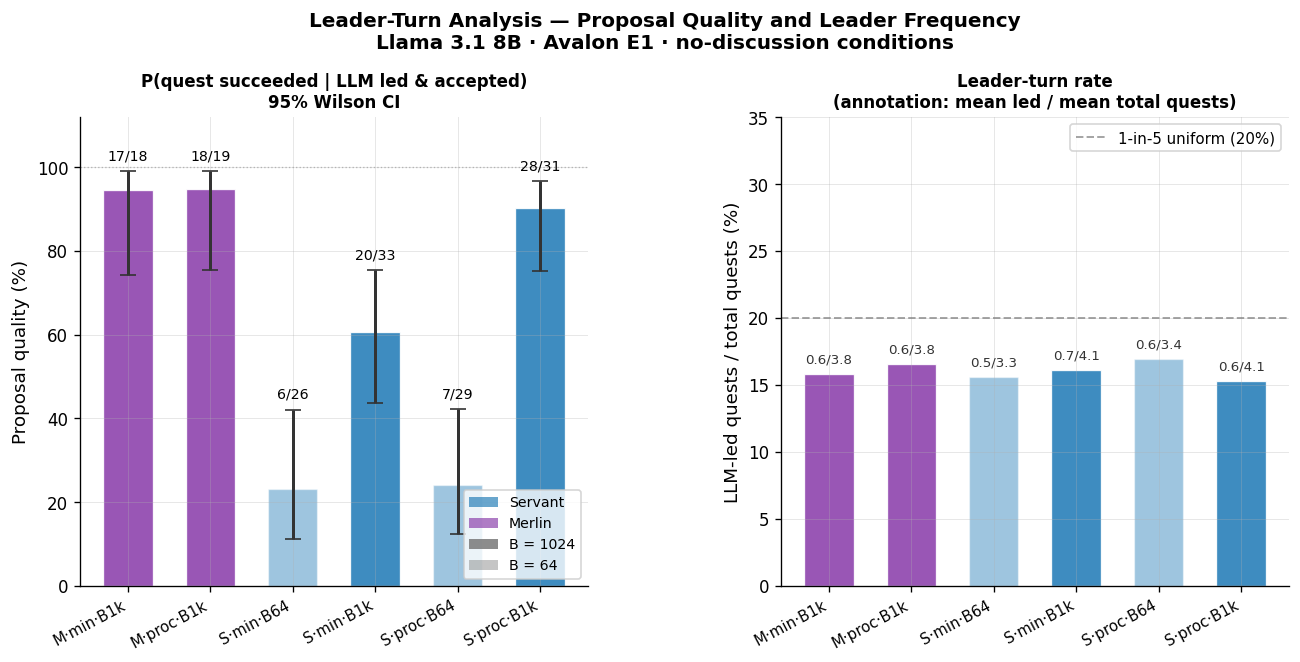

Saved: fig_e1_leader_analysis.png


In [14]:

# ── Figure 8: Proposal quality (all conditions) + leader-turn rate ─────────────
# total_quests counted from JSONL quest_result events.
# llm_led counted via team_vote_result.accepted (not team composition matching).

game_records = []

for run_dir in sorted(VALID_RUN_DIRS):
    for fpath in sorted(run_dir.glob('trial_*.jsonl')):
        lines = fpath.read_text().splitlines()
        if not lines:
            continue
        events = [json.loads(l) for l in lines if l.strip()]
        start = next((e for e in events if e['event'] == 'trial_start'), None)
        if not start:
            continue
        cond = start['condition']
        if cond.get('with_discussion', False):
            continue

        vote_map = {(e['quest_turn'], e['round']): e['accepted']
                    for e in events if e['event'] == 'team_vote_result'}
        n_quests = sum(1 for e in events if e['event'] == 'quest_result')
        llm_led  = sum(
            1 for e in events
            if e['event'] == 'team_proposed'
            and e.get('is_llm_decision')
            and vote_map.get((e['quest_turn'], e['round']), False)
        )

        game_records.append({
            'llm_role':       cond['llm_role'],
            'prompt_variant': cond['prompt_variant'],
            'budget':         cond['budget'],
            'n_quests':       n_quests,
            'llm_led':        llm_led,
        })

games_df = pd.DataFrame(game_records)
leader_rate = (games_df
               .groupby(['llm_role', 'prompt_variant', 'budget'])
               .agg(mean_quests=('n_quests', 'mean'),
                    mean_led=('llm_led', 'mean'),
                    n_games=('n_quests', 'count'))
               .reset_index())
leader_rate['leader_pct'] = (
    100 * leader_rate['mean_led'] / leader_rate['mean_quests'].replace(0, np.nan)
)

print("Leader-turn stats (no discussion):")
print(leader_rate[['llm_role','prompt_variant','budget','n_games',
                   'mean_quests','mean_led','leader_pct']].round(2).to_string(index=False))

# Proposal quality (accepted leader proposals, no discussion)
no_disc_acc = accepted_df[~accepted_df['with_discussion']].copy()
pq_all = win_rate_table(
    no_disc_acc.rename(columns={'succeeded': 'llm_win'}),
    ['llm_role', 'prompt_variant', 'budget']
).sort_values(['llm_role', 'prompt_variant', 'budget'])

COND_LABELS = {
    ('Merlin',  'minimal',    1024): 'M·min·B1k',
    ('Merlin',  'procedural', 1024): 'M·proc·B1k',
    ('Servant', 'minimal',    64):   'S·min·B64',
    ('Servant', 'minimal',    1024): 'S·min·B1k',
    ('Servant', 'procedural', 64):   'S·proc·B64',
    ('Servant', 'procedural', 1024): 'S·proc·B1k',
}
ordered_keys = list(COND_LABELS.keys())
xs = np.arange(len(ordered_keys))

pq_lookup = {(r['llm_role'], r['prompt_variant'], int(r['budget'])): r
             for _, r in pq_all.iterrows()}
lr_lookup  = {(r['llm_role'], r['prompt_variant'], int(r['budget'])): r
              for _, r in leader_rate.iterrows()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.subplots_adjust(top=0.82, wspace=0.38)

# Left — proposal quality (conditional, accepted proposals)
ax = axes[0]
for i, key in enumerate(ordered_keys):
    row = pq_lookup.get(key)
    if row is None:
        continue
    color = ROLE_COLORS[key[0]]
    alpha = 0.9 if key[2] == 1024 else 0.45
    p, lo, hi = float(row['win_rate']), float(row['ci_lo']), float(row['ci_hi'])
    n, wins   = int(row['n']), int(row['wins'])

    ax.bar(i, p * 100, 0.6, color=color, alpha=alpha, edgecolor='white', linewidth=0.8)
    ax.errorbar(i, p * 100,
                yerr=[[max(0., (p - lo) * 100)], [max(0., (hi - p) * 100)]],
                fmt='none', color='#333', elinewidth=1.8, capsize=5, zorder=5)
    label_y = min(hi * 100 + 2, 104)
    ax.text(i, label_y, f"{wins}/{n}", ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(xs)
ax.set_xticklabels([COND_LABELS[k] for k in ordered_keys], rotation=28, ha='right', fontsize=9)
ax.set_ylim(0, 112)
ax.set_ylabel('Proposal quality (%)', fontsize=11)
ax.set_title('P(quest succeeded | LLM led & accepted)\n95% Wilson CI', fontsize=10, fontweight='bold')
ax.axhline(100, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax.legend(handles=[
    mpatches.Patch(facecolor=ROLE_COLORS['Servant'], alpha=0.7, label='Servant'),
    mpatches.Patch(facecolor=ROLE_COLORS['Merlin'],  alpha=0.7, label='Merlin'),
    mpatches.Patch(facecolor='gray', alpha=0.9, label='B = 1024'),
    mpatches.Patch(facecolor='gray', alpha=0.45, label='B = 64'),
], fontsize=8.5, loc='lower right')

# Right — leader-turn rate
ax = axes[1]
for i, key in enumerate(ordered_keys):
    row = lr_lookup.get(key)
    if row is None:
        continue
    color = ROLE_COLORS[key[0]]
    alpha = 0.9 if key[2] == 1024 else 0.45
    pct   = float(row['leader_pct'])
    led   = float(row['mean_led'])
    total = float(row['mean_quests'])

    ax.bar(i, pct, 0.6, color=color, alpha=alpha, edgecolor='white', linewidth=0.8)
    ax.text(i, pct + 0.6, f"{led:.1f}/{total:.1f}",
            ha='center', va='bottom', fontsize=8, color='#333')

ax.set_xticks(xs)
ax.set_xticklabels([COND_LABELS[k] for k in ordered_keys], rotation=28, ha='right', fontsize=9)
ax.axhline(20, color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
           label='1-in-5 uniform (20%)')
ax.set_ylim(0, 35)
ax.set_ylabel('LLM-led quests / total quests (%)', fontsize=11)
ax.set_title('Leader-turn rate\n(annotation: mean led / mean total quests)', fontsize=10, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Leader-Turn Analysis — Proposal Quality and Leader Frequency\n'
             'Llama 3.1 8B · Avalon E1 · no-discussion conditions',
             fontsize=12, fontweight='bold', y=0.98)

plt.savefig('fig_e1_leader_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_leader_analysis.png')


Random-team clean baseline (weighted by actual team sizes): 20.1%
  P(clean|size=2) = 30%,  P(clean|size=3) = 10%


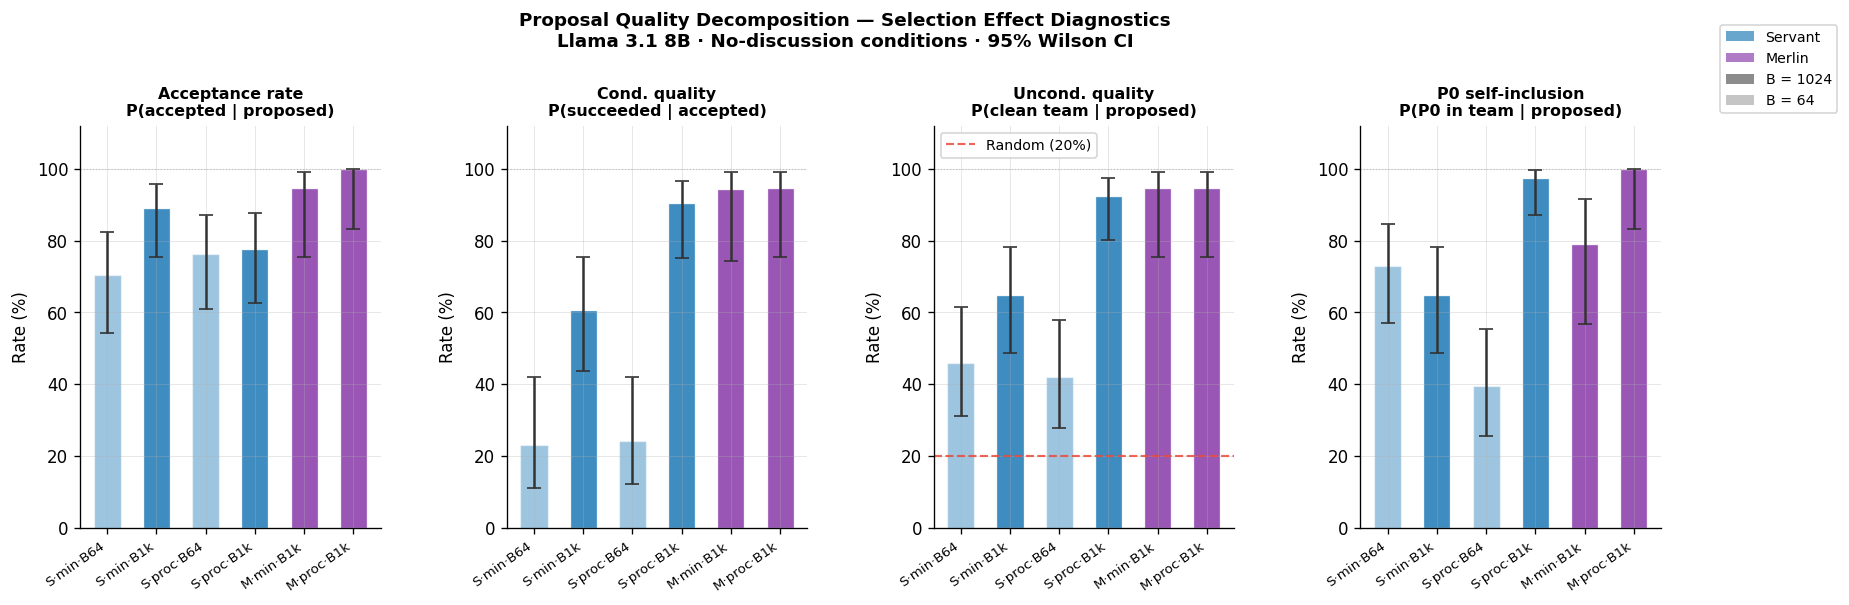

Saved: fig_e1_proposal_decomposition.png

Proposal quality decomposition (primary metric = Proposal Regret = 1 − uncond_qual):
Condition           N   Acc%   Cond%  Uncond%  Regret%  P0inc%  N_acc
------------------------------------------------------------------
S·min·B64          37   70.3    23.1     45.9     54.1    73.0     26
S·min·B1k          37   89.2    60.6     64.9     35.1    64.9     33
S·proc·B64         38   76.3    24.1     42.1     57.9    39.5     29
S·proc·B1k         40   77.5    90.3     92.5      7.5    97.5     31
M·min·B1k          19   94.7    94.4     94.7      5.3    78.9     18
M·proc·B1k         19  100.0    94.7     94.7      5.3   100.0     19

Random clean baseline: 20.1%  (size-2: 30%, size-3: 10%)
Proposal regret → 0% is the ideal; random-guess ceiling ≈ 80% regret.


In [15]:
# ── Figure 9: Proposal quality decomposition — selection effect diagnostics ────
# Three metrics computed over ALL LLM proposals (no discussion, primary cells):
#   (a) Acceptance rate  = P(accepted | LLM proposed)      — selection filter check
#   (b) Cond. quality    = P(succeeded | accepted)          — current metric (fixed)
#   (c) Uncond. quality  = P(team is clean | proposed)      — cleanest measure
#   (d) P0 self-inclusion = P(team includes P0 | proposed)  — confound check
# Red dashed = random-team clean baseline (weighted by actual proposal team sizes).
# Proposal regret = 1 − uncond_qual (primary metric: optimal policy → 0%).

def _random_clean_prob(k, n_players=5, n_evil=2):
    n_good = n_players - n_evil
    return comb(n_good, k) / comb(n_players, k) if k <= n_good else 0.0

PRIM_COND_KEYS = [
    ('Servant', 'minimal',    64),
    ('Servant', 'minimal',    1024),
    ('Servant', 'procedural', 64),
    ('Servant', 'procedural', 1024),
    ('Merlin',  'minimal',    1024),
    ('Merlin',  'procedural', 1024),
]
PRIM_LABELS = {
    ('Servant', 'minimal',    64):   'S·min·B64',
    ('Servant', 'minimal',    1024): 'S·min·B1k',
    ('Servant', 'procedural', 64):   'S·proc·B64',
    ('Servant', 'procedural', 1024): 'S·proc·B1k',
    ('Merlin',  'minimal',    1024): 'M·min·B1k',
    ('Merlin',  'procedural', 1024): 'M·proc·B1k',
}

no_disc_prop = prop_df[~prop_df['with_discussion']].copy()

# Random baseline: weighted average over actual team sizes in no-disc proposals
rand_base = no_disc_prop['team_size'].apply(_random_clean_prob).mean()
print(f"Random-team clean baseline (weighted by actual team sizes): {rand_base*100:.1f}%")
print(f"  P(clean|size=2) = {_random_clean_prob(2)*100:.0f}%,  P(clean|size=3) = {_random_clean_prob(3)*100:.0f}%")

# Compute all four metrics with Wilson CI
metrics = {}
for key in PRIM_COND_KEYS:
    role, variant, budget = key
    sub = no_disc_prop[(no_disc_prop['llm_role']==role) &
                       (no_disc_prop['prompt_variant']==variant) &
                       (no_disc_prop['budget']==budget)]
    if sub.empty:
        continue
    n       = len(sub)
    acc_sub = sub[sub['accepted']]
    n_acc   = len(acc_sub)
    suc_w   = int(acc_sub['succeeded'].sum()) if not acc_sub.empty else 0

    metrics[key] = {
        'n':           n,
        'n_acc':       n_acc,
        'acceptance':  wilson_ci(int(sub['accepted'].sum()), n),
        'uncond_qual': wilson_ci(int(sub['team_is_clean'].sum()), n),
        'cond_qual':   wilson_ci(suc_w, n_acc) if n_acc > 0 else (np.nan, np.nan, np.nan),
        'p0_inclusion':wilson_ci(int(sub['includes_p0'].sum()), n),
    }

# Plot 4-panel figure
fig, axes = plt.subplots(1, 4, figsize=(17, 5))
fig.subplots_adjust(wspace=0.42, top=0.78)

panel_configs = [
    ('acceptance',   'Acceptance rate\nP(accepted | proposed)',   None),
    ('cond_qual',    'Cond. quality\nP(succeeded | accepted)',     None),
    ('uncond_qual',  'Uncond. quality\nP(clean team | proposed)',  rand_base),
    ('p0_inclusion', 'P0 self-inclusion\nP(P0 in team | proposed)', None),
]

xs    = np.arange(len(PRIM_COND_KEYS))
bar_w = 0.55

for ax, (mkey, title, baseline) in zip(axes, panel_configs):
    for i, key in enumerate(PRIM_COND_KEYS):
        if key not in metrics:
            continue
        p, lo, hi = metrics[key][mkey]
        if np.isnan(p):
            continue
        color = ROLE_COLORS[key[0]]
        alpha = 0.9 if key[2] == 1024 else 0.45
        ax.bar(i, p * 100, bar_w, color=color, alpha=alpha, edgecolor='white', linewidth=0.8)
        ax.errorbar(i, p * 100,
                    yerr=[[max(0., (p - lo) * 100)], [max(0., (hi - p) * 100)]],
                    fmt='none', color='#333', elinewidth=1.5, capsize=4, zorder=5)
    if baseline is not None:
        ax.axhline(baseline * 100, color='#e74c3c', linestyle='--', linewidth=1.3,
                   alpha=0.85, label=f'Random ({baseline*100:.0f}%)')
        ax.legend(fontsize=8.5, loc='upper left')
    ax.set_xticks(xs)
    ax.set_xticklabels([PRIM_LABELS[k] for k in PRIM_COND_KEYS], rotation=35, ha='right', fontsize=8)
    ax.set_ylim(0, 112)
    ax.set_ylabel('Rate (%)', fontsize=10)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.axhline(100, color='gray', linestyle=':', linewidth=0.7, alpha=0.4)

fig.suptitle('Proposal Quality Decomposition — Selection Effect Diagnostics\n'
             'Llama 3.1 8B · No-discussion conditions · 95% Wilson CI',
             fontsize=11, fontweight='bold', y=0.97)
fig.legend(handles=[
    mpatches.Patch(facecolor=ROLE_COLORS['Servant'], alpha=0.7, label='Servant'),
    mpatches.Patch(facecolor=ROLE_COLORS['Merlin'],  alpha=0.7, label='Merlin'),
    mpatches.Patch(facecolor='gray', alpha=0.9,  label='B = 1024'),
    mpatches.Patch(facecolor='gray', alpha=0.45, label='B = 64'),
], loc='upper right', fontsize=8.5, bbox_to_anchor=(0.99, 0.96))

plt.savefig('fig_e1_proposal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_proposal_decomposition.png')

# Summary table including proposal regret (primary metric)
print('\nProposal quality decomposition (primary metric = Proposal Regret = 1 − uncond_qual):')
print(f"{'Condition':<16} {'N':>4} {'Acc%':>6} {'Cond%':>7} {'Uncond%':>8} {'Regret%':>8} {'P0inc%':>7} {'N_acc':>6}")
print('-' * 66)
for key in PRIM_COND_KEYS:
    if key not in metrics:
        continue
    m = metrics[key]
    p_acc  = m['acceptance'][0]  * 100
    p_con  = m['cond_qual'][0]   * 100 if not np.isnan(m['cond_qual'][0]) else float('nan')
    p_unc  = m['uncond_qual'][0] * 100
    regret = 100 - p_unc
    p_p0   = m['p0_inclusion'][0]* 100
    print(f"{PRIM_LABELS[key]:<16} {m['n']:>4} {p_acc:>6.1f} {p_con:>7.1f} {p_unc:>8.1f} {regret:>8.1f} {p_p0:>7.1f} {m['n_acc']:>6}")

print(f"\nRandom clean baseline: {rand_base*100:.1f}%  "
      f"(size-2: {_random_clean_prob(2)*100:.0f}%, size-3: {_random_clean_prob(3)*100:.0f}%)")
print('Proposal regret → 0% is the ideal; random-guess ceiling ≈ 80% regret.')


Vote consistency: P(LLM approved own proposal | it was LLM's proposal)
Condition            B  All props  Clean props  Dirty props
------------------------------------------------------------
S·min·B64           64    19% [9–34%] n=37   35% [17–59%] n=17     5% [1–24%] n=20
S·min·B1k         1024   84% [69–92%] n=37   83% [64–93%] n=24   85% [58–96%] n=13
S·proc·B64          64   32% [19–47%] n=38   44% [23–67%] n=16   23% [10–43%] n=22
S·proc·B1k        1024   75% [60–86%] n=40   76% [60–87%] n=37    67% [21–94%] n=3
M·min·B1k         1024   89% [69–97%] n=19   94% [74–99%] n=18      0% [0–79%] n=1
M·proc·B1k        1024  100% [83–100%] n=19  100% [82–100%] n=18  100% [21–100%] n=1

Interpretation: if P(approved | clean proposal) << 1 at B=64,
the LLM is rejecting its own clean proposals — B=64 voting incoherence confirmed.


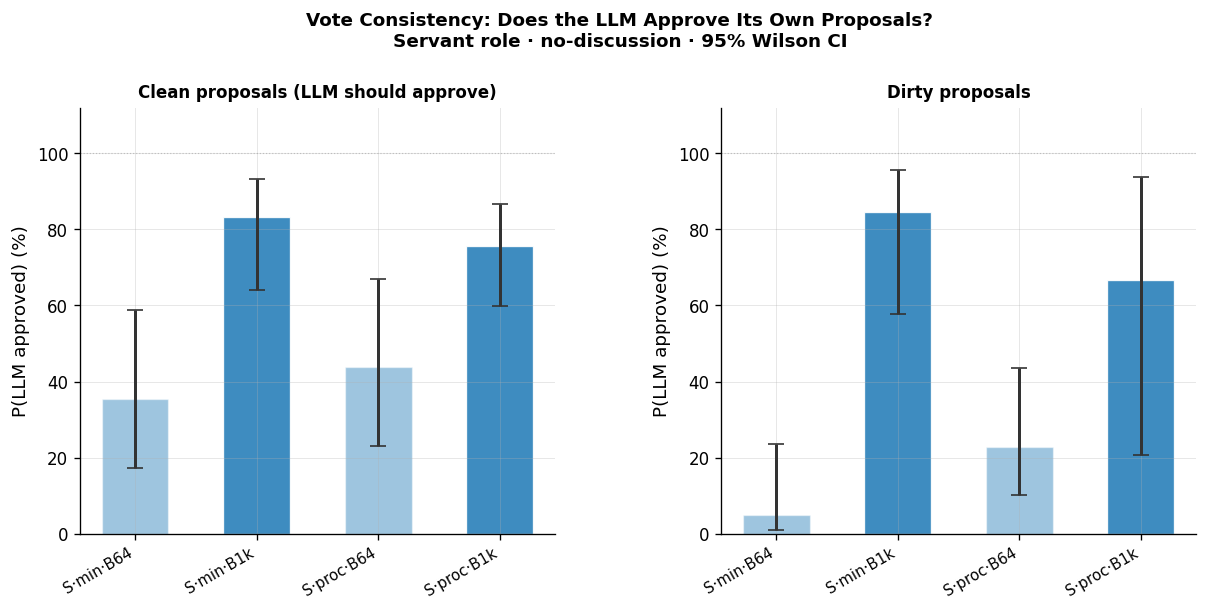

Saved: fig_e1_vote_consistency.png


In [16]:
# ── Vote consistency analysis (Tier 1b) ───────────────────────────────────────
# At B=64, conditional quality (~23%) is far below unconditional quality (~45%).
# Hypothesis: the LLM frequently rejects its own clean proposals when voting
# (separate team-vote call, also budget-truncated) — B=64 creates incoherence
# between the two decision calls.
#
# Metric: P(LLM approved own proposal | it was LLM's proposal)
# LLM is always P0, so: votes[0] in the team_vote_result for that (quest_turn, round)

vote_records = []

for run_dir in sorted(VALID_RUN_DIRS):
    run_name = run_dir.name.split('__')[0]
    for fpath in sorted(run_dir.glob('trial_*.jsonl')):
        lines = fpath.read_text().splitlines()
        if not lines:
            continue
        events = [json.loads(l) for l in lines if l.strip()]
        start  = next((e for e in events if e['event'] == 'trial_start'), None)
        if not start:
            continue
        cond = start['condition']
        if cond.get('with_discussion', False):
            continue  # skip discussion cells

        # Index vote results by (quest_turn, round)
        vote_by_key = {
            (e['quest_turn'], e['round']): e
            for e in events if e['event'] == 'team_vote_result'
        }
        gs = next((e for e in events if e['event'] == 'game_start'), None)
        if not gs:
            continue
        evil_players = frozenset(
            i for i, r in enumerate(gs['role_names']) if r in ('Assassin', 'Minion')
        )

        for ev in events:
            if ev['event'] == 'team_proposed' and ev.get('is_llm_decision'):
                qt  = ev['quest_turn']
                rnd = ev['round']
                team = frozenset(ev['team'])
                vote_ev = vote_by_key.get((qt, rnd))
                if vote_ev is None:
                    continue
                llm_approved = bool(vote_ev['votes'][0])  # LLM is always P0
                team_clean   = len(team & evil_players) == 0
                vote_records.append({
                    'run_name':       run_name,
                    'budget':         cond['budget'],
                    'llm_role':       cond['llm_role'],
                    'prompt_variant': cond['prompt_variant'],
                    'team_clean':     team_clean,
                    'llm_approved':   llm_approved,
                })

vote_df = pd.DataFrame(vote_records)

# Compute P(LLM approved own proposal) by condition and team cleanliness
print('Vote consistency: P(LLM approved own proposal | it was LLM\'s proposal)')
print(f"{'Condition':<16} {'B':>5} {'All props':>10} {'Clean props':>12} {'Dirty props':>12}")
print('-' * 60)

for key in PRIM_COND_KEYS:
    role, variant, budget = key
    sub = vote_df[(vote_df['llm_role']==role) &
                  (vote_df['prompt_variant']==variant) &
                  (vote_df['budget']==budget)]
    if sub.empty:
        continue

    def _pct(s):
        n = len(s)
        if n == 0:
            return 'n/a'
        k = int(s['llm_approved'].sum())
        p = k / n
        lo = wilson_ci(k, n)[1]
        hi = wilson_ci(k, n)[2]
        return f'{p*100:.0f}% [{lo*100:.0f}–{hi*100:.0f}%] n={n}'

    print(f"{PRIM_LABELS[key]:<16} {budget:>5}  {_pct(sub):>18}  "
          f"{_pct(sub[sub['team_clean']]):>18}  {_pct(sub[~sub['team_clean']]):>18}")

print()
print('Interpretation: if P(approved | clean proposal) << 1 at B=64,')
print('the LLM is rejecting its own clean proposals — B=64 voting incoherence confirmed.')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.subplots_adjust(wspace=0.35, top=0.82)

SERVANT_KEYS = [k for k in PRIM_COND_KEYS if k[0] == 'Servant']
labels_s = [PRIM_LABELS[k] for k in SERVANT_KEYS]

for ax, clean_flag, subtitle in zip(axes, [True, False],
                                    ['Clean proposals (LLM should approve)', 'Dirty proposals']):
    vals, los, his = [], [], []
    for key in SERVANT_KEYS:
        role, variant, budget = key
        sub = vote_df[(vote_df['llm_role']==role) &
                      (vote_df['prompt_variant']==variant) &
                      (vote_df['budget']==budget) &
                      (vote_df['team_clean']==clean_flag)]
        if sub.empty:
            vals.append(np.nan); los.append(np.nan); his.append(np.nan)
            continue
        k = int(sub['llm_approved'].sum())
        n = len(sub)
        p, lo, hi = wilson_ci(k, n)
        vals.append(p); los.append(lo); his.append(hi)

    for i, (p, lo, hi) in enumerate(zip(vals, los, his)):
        if np.isnan(p):
            continue
        color = ROLE_COLORS['Servant']
        alpha = 0.9 if SERVANT_KEYS[i][2] == 1024 else 0.45
        ax.bar(i, p * 100, 0.55, color=color, alpha=alpha, edgecolor='white', linewidth=0.8)
        ax.errorbar(i, p * 100,
                    yerr=[[max(0., (p - lo) * 100)], [max(0., (hi - p) * 100)]],
                    fmt='none', color='#333', elinewidth=1.8, capsize=5, zorder=5)

    ax.set_xticks(range(len(labels_s)))
    ax.set_xticklabels(labels_s, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 112)
    ax.axhline(100, color='gray', linestyle=':', linewidth=0.7, alpha=0.4)
    ax.set_ylabel('P(LLM approved) (%)', fontsize=11)
    ax.set_title(subtitle, fontsize=10, fontweight='bold')

fig.suptitle('Vote Consistency: Does the LLM Approve Its Own Proposals?\n'
             'Servant role · no-discussion · 95% Wilson CI',
             fontsize=11, fontweight='bold', y=0.98)
plt.savefig('fig_e1_vote_consistency.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_vote_consistency.png')


---
## Llama-as-Summarizer Ablation (L-S-llamasumm)

*Does the summarizer model matter?*

The primary cells use **Sonnet** (`claude-sonnet-4-6`) to summarize each quest after it resolves —
a fixed-template, facts-only structured summary. This creates a potential confound: is the
summarizer model doing reasoning for the player model, or is it truly just a recorder?

The **L-S-llamasumm** ablation answers this directly by replacing Sonnet with **Llama 3.1 8B**
(via SGLang, same template, same constraints) while holding everything else constant: Servant role,
minimal prompt, B=1024, N=30 — identical to the S·min·B1k baseline.

If proposal quality metrics are statistically indistinguishable between the two summarizer models,
that validates the design: the summary is acting as a memory aid (providing factual context),
not as a reasoning proxy. If quality drops, it would suggest the Sonnet summarizer was contributing
non-factual signal (e.g., inferences) despite the FACTS ONLY constraint.

**Baseline for comparison**: S·min·B1k (N=50, Sonnet summarizer) from `prop_df`.

In [17]:
# ── L-S-llamasumm: parse JSONL + compute 4 proposal-quality metrics ────────────
# Identical parsing logic to cell 9da3b594; loaded from llamasumm run dirs.
# Baseline = prop_df rows for S·min·B1k (Sonnet summarizer, N=50).

LS_RUN_DIRS = [d for d in RUNS_DIR.iterdir()
               if d.is_dir() and d.name.startswith('avalon_e1_servant_llamasumm__')]

print(f"Llamasumm run directories found: {len(LS_RUN_DIRS)}")
for d in sorted(LS_RUN_DIRS):
    print(f"  {d.name}")

ls_proposal_records = []

for run_dir in sorted(LS_RUN_DIRS):
    for fpath in sorted(run_dir.glob('trial_*.jsonl')):
        lines = fpath.read_text().splitlines()
        if not lines:
            continue
        events = [json.loads(l) for l in lines if l.strip()]

        start = next((e for e in events if e['event'] == 'trial_start'), None)
        if not start:
            continue
        cond = start['condition']

        gs = next((e for e in events if e['event'] == 'game_start'), None)
        if not gs:
            continue
        evil_players = frozenset(
            i for i, r in enumerate(gs['role_names']) if r in ('Assassin', 'Minion')
        )

        vote_by_round = {}
        for ev in events:
            if ev['event'] == 'team_vote_result':
                vote_by_round[(ev['quest_turn'], ev['round'])] = ev

        quest_outcomes = {}
        for ev in events:
            if ev['event'] == 'quest_result':
                quest_outcomes[ev['quest_turn']] = ev

        for ev in events:
            if ev['event'] == 'team_proposed' and ev.get('is_llm_decision'):
                qt   = ev['quest_turn']
                rnd  = ev['round']
                team = frozenset(ev['team'])

                vote     = vote_by_round.get((qt, rnd))
                accepted = bool(vote and vote.get('accepted', False))

                q_ev      = quest_outcomes.get(qt) if accepted else None
                succeeded = q_ev['succeeded'] if q_ev else None

                ls_proposal_records.append({
                    'seed':        cond['seed'],
                    'quest_turn':  qt,
                    'round':       rnd,
                    'team_size':   len(team),
                    'accepted':    accepted,
                    'team_is_clean': len(team & evil_players) == 0,
                    'includes_p0': 0 in team,
                    'succeeded':   succeeded,
                })

ls_prop_df = pd.DataFrame(ls_proposal_records)
ls_acc_df  = ls_prop_df[ls_prop_df['accepted']].copy()

print(f"\nLlamasumm proposals parsed: {len(ls_prop_df)}")
print(f"  Accepted: {len(ls_acc_df)}  |  Rejected: {len(ls_prop_df) - len(ls_acc_df)}")

# Compute 4 metrics for llamasumm
def _four_metrics(prop_sub):
    n       = len(prop_sub)
    acc_sub = prop_sub[prop_sub['accepted']]
    n_acc   = len(acc_sub)
    suc_w   = int(acc_sub['succeeded'].sum()) if not acc_sub.empty else 0
    return {
        'n':           n,
        'n_acc':       n_acc,
        'acceptance':  wilson_ci(int(prop_sub['accepted'].sum()), n),
        'cond_qual':   wilson_ci(suc_w, n_acc) if n_acc > 0 else (np.nan, np.nan, np.nan),
        'uncond_qual': wilson_ci(int(prop_sub['team_is_clean'].sum()), n),
        'p0_inclusion':wilson_ci(int(prop_sub['includes_p0'].sum()), n),
    }

ls_metrics = _four_metrics(ls_prop_df)

# Baseline: S·min·B1k (Sonnet summarizer, N=50)
baseline_prop = prop_df[
    (prop_df['run_name'] == 'avalon_e1_servant_minimal') &
    (prop_df['budget'] == 1024) &
    (~prop_df['with_discussion'])
].copy()
base_metrics = _four_metrics(baseline_prop)

# Print comparison table
print('\n=== Llamasumm vs Sonnet-summarizer (S·min·B1k) — Proposal Quality ===')
print(f'{"Metric":<22} {"Sonnet (N=50)":>14}  {"Llama-summ (N=?)":>16}')
print('-' * 56)

def _fmt(tup):
    p, lo, hi = tup
    if np.isnan(p):
        return '       n/a'
    return f"{p*100:>5.1f}% [{lo*100:.0f}–{hi*100:.0f}%]"

for mkey, label in [
    ('acceptance',   'Acceptance rate'),
    ('cond_qual',    'Cond. quality'),
    ('uncond_qual',  'Uncond. quality'),
    ('p0_inclusion', 'P0 self-inclusion'),
]:
    print(f'{label:<22}  {_fmt(base_metrics[mkey]):>18}  {_fmt(ls_metrics[mkey]):>18}')

print(f'\nBaseline N: {base_metrics["n"]} proposals, {base_metrics["n_acc"]} accepted')
print(f'Llamasumm N: {ls_metrics["n"]} proposals, {ls_metrics["n_acc"]} accepted')


Llamasumm run directories found: 1
  avalon_e1_servant_llamasumm__71536ca0

Llamasumm proposals parsed: 22
  Accepted: 17  |  Rejected: 5

=== Llamasumm vs Sonnet-summarizer (S·min·B1k) — Proposal Quality ===
Metric                  Sonnet (N=50)  Llama-summ (N=?)
--------------------------------------------------------
Acceptance rate             89.2% [75–96%]      77.3% [57–90%]
Cond. quality               60.6% [44–75%]      70.6% [47–87%]
Uncond. quality             64.9% [49–78%]      77.3% [57–90%]
P0 self-inclusion           64.9% [49–78%]      63.6% [43–80%]

Baseline N: 37 proposals, 33 accepted
Llamasumm N: 22 proposals, 17 accepted


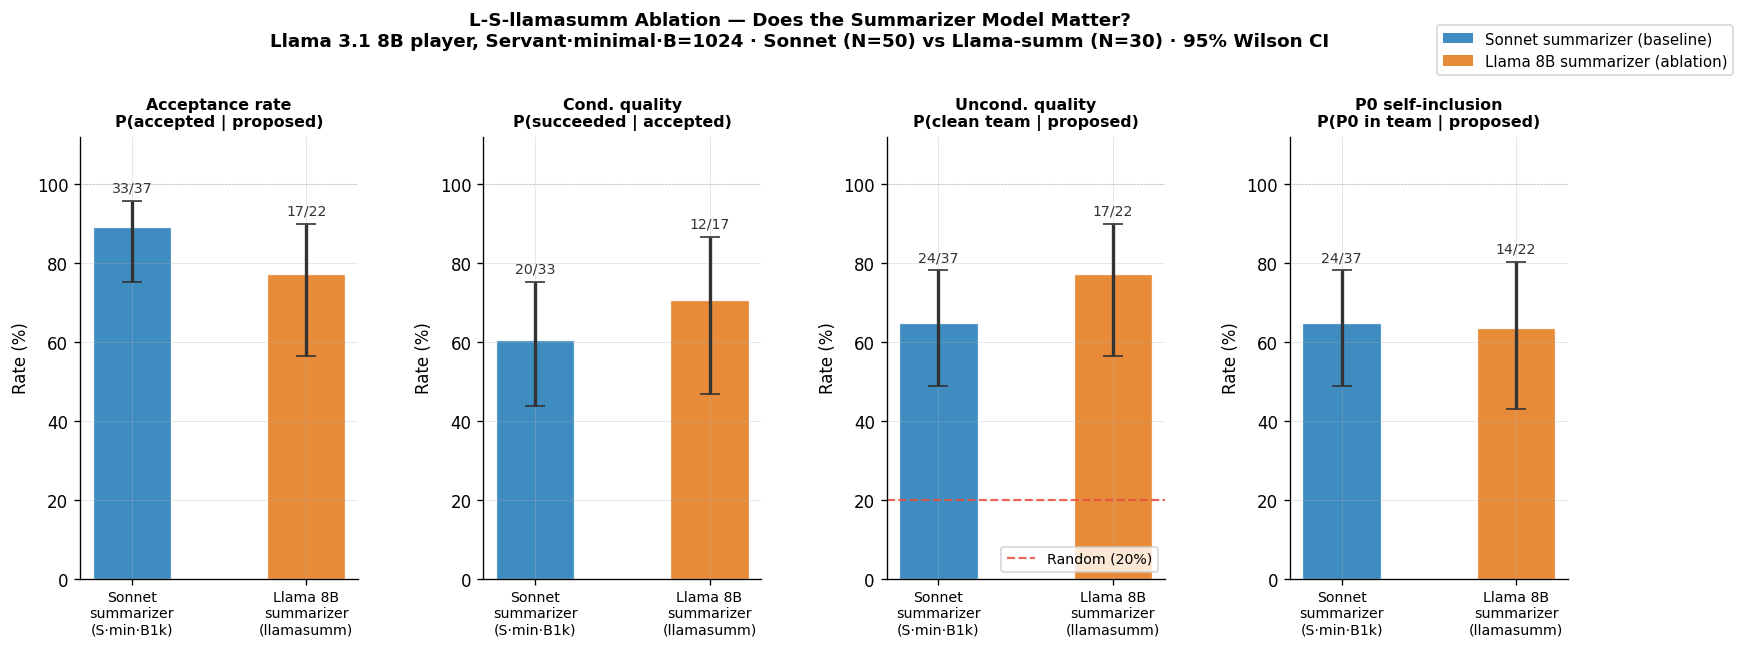

Saved: fig_e1_llamasumm_comparison.png

Numerical comparison (Sonnet vs Llama-summ):
  Acceptance rate       : Sonnet 89.2%  Llama 77.3%  Δ=-11.9pp
  Cond. quality         : Sonnet 60.6%  Llama 70.6%  Δ=+10.0pp
  Uncond. quality       : Sonnet 64.9%  Llama 77.3%  Δ=+12.4pp
  P0 self-inclusion     : Sonnet 64.9%  Llama 63.6%  Δ=-1.2pp


In [18]:
# ── Figure 10: Llamasumm vs Sonnet-summarizer — 4-metric side-by-side ──────────

METRIC_CONFIGS = [
    ('acceptance',   'Acceptance rate\nP(accepted | proposed)',   'n'),
    ('cond_qual',    'Cond. quality\nP(succeeded | accepted)',     'n_acc'),
    ('uncond_qual',  'Uncond. quality\nP(clean team | proposed)',  'n'),
    ('p0_inclusion', 'P0 self-inclusion\nP(P0 in team | proposed)', 'n'),
]

CONDITIONS = [
    ('Sonnet\nsummarizer\n(S·min·B1k)', base_metrics,  '#2980b9', 0.9),
    ('Llama 8B\nsummarizer\n(llamasumm)', ls_metrics,  '#e67e22', 0.9),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5.5))
fig.subplots_adjust(wspace=0.45, top=0.78)

xs    = np.arange(len(CONDITIONS))
bar_w = 0.45

for ax, (mkey, title, denom_key) in zip(axes, METRIC_CONFIGS):
    for i, (label, m, color, alpha) in enumerate(CONDITIONS):
        p, lo, hi = m[mkey]
        denom = m[denom_key]
        if np.isnan(p) or denom == 0:
            ax.text(i, 5, 'n/a', ha='center', va='bottom', fontsize=9, color='gray')
            continue
        ax.bar(i, p * 100, bar_w, color=color, alpha=alpha, edgecolor='white', linewidth=0.8)
        ax.errorbar(i, p * 100,
                    yerr=[[max(0., (p - lo) * 100)], [max(0., (hi - p) * 100)]],
                    fmt='none', color='#333', elinewidth=2, capsize=6, zorder=5)
        ax.text(i, hi * 100 + 1.5,
                f"{int(round(p * denom))}/{denom}",
                ha='center', va='bottom', fontsize=8.5, color='#333')

    if mkey == 'uncond_qual':
        ax.axhline(rand_base * 100, color='#e74c3c', linestyle='--', linewidth=1.3,
                   alpha=0.85, label=f'Random ({rand_base*100:.0f}%)')
        ax.legend(fontsize=8.5, loc='lower right')

    ax.set_xticks(xs)
    ax.set_xticklabels([c[0] for c in CONDITIONS], fontsize=8.5)
    ax.set_ylim(0, 112)
    ax.set_ylabel('Rate (%)', fontsize=10)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.axhline(100, color='gray', linestyle=':', linewidth=0.7, alpha=0.4)

fig.suptitle('L-S-llamasumm Ablation — Does the Summarizer Model Matter?\n'
             'Llama 3.1 8B player, Servant·minimal·B=1024 · Sonnet (N=50) vs Llama-summ (N=30) · 95% Wilson CI',
             fontsize=11, fontweight='bold', y=0.97)

patches_legend = [
    mpatches.Patch(facecolor='#2980b9', alpha=0.9, label='Sonnet summarizer (baseline)'),
    mpatches.Patch(facecolor='#e67e22', alpha=0.9, label='Llama 8B summarizer (ablation)'),
]
fig.legend(handles=patches_legend, loc='upper right', fontsize=9, bbox_to_anchor=(0.99, 0.96))

plt.savefig('fig_e1_llamasumm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_e1_llamasumm_comparison.png')

# Numerical comparison
print('\nNumerical comparison (Sonnet vs Llama-summ):')
for mkey, label, denom_key in METRIC_CONFIGS:
    p_s, lo_s, hi_s = base_metrics[mkey]
    p_l, lo_l, hi_l = ls_metrics[mkey]
    diff = (p_l - p_s) * 100 if not np.isnan(p_l) else float('nan')
    print(f"  {label.split(chr(10))[0]:<22}: Sonnet {p_s*100:.1f}%  Llama {p_l*100:.1f}%  Δ={diff:+.1f}pp")


---

## Theoretical Win-Rate Ceiling

*What is the maximum win rate achievable by a perfect LLM proposer under the structural constraints of this experiment?*

The naive-bot setup creates a structural ceiling well below 100%:
- The LLM's **team vote is irrelevant** (all proposals pass on first attempt)
- The LLM's **only lever is proposals when it is the leader**, ~16% of quest slots
- Evil bots always sabotage their quests; Bot Servant proposes random teams

We compute the ceiling by Monte Carlo with a **perfect-LLM stub** that always proposes a clean team when leader. This converts observed win rate into an **efficiency score**:

> efficiency = observed win rate / ceiling win rate

If the ceiling is 12% and S·proc·B1k achieves 8.5%, efficiency = **71%** — the model captures 71% of the available structural headroom.

Two conditions:
- **Fixed-position** (original E1): Evil always at P3/P4
- **Shuffled** (corrected setup): Evil at any of P1–P4

In [ ]:
# ── Theoretical win-rate ceiling (Monte Carlo, perfect LLM proposer) ──────────
#
# Game config (5-player AvalonBench engine):
#   Quest sizes   : [2, 3, 2, 3, 3]
#   Fails needed  : [1, 1, 1, 1, 1]  (no double-fail rule in 5-player)
#   Good wins     : 3 quest successes + Merlin not assassinated
#   Evil wins     : 3 quest failures  (or Merlin assassinated)
#
# Structural facts with naive bots:
#   Every proposal accepted on attempt 1 -> leader rotates exactly once per quest
#   Clean team : Merlin+1 + Servant+1 + LLM+1 = 3/5 approved
#   Dirty team : Evil1+1 + Evil2+1 + Servant+1 = 3/5 approved
#
# Quest success probability for each leader role:
#   LLM (perfect) : 1.0  (always proposes all-Good)
#   Bot Merlin    : 1.0  (always proposes all-Good)
#   Bot Servant   : C(3,k)/C(5,k)  k=2->30%  k=3->10%
#   Bot Evil      : 0.0  (always includes >=1 Evil)
#
# Merlin assassination (naive Assassin):
#   Picks uniformly from 4 non-Assassin players -> P(hit Merlin) = 1/4
#   -> P(Merlin survives | Good won 3 quests) = 3/4

import numpy as np
from math import comb
from scipy import stats as _stats

QUEST_SIZES       = [2, 3, 2, 3, 3]
N_PLAYERS         = 5
N_GOOD            = 3
P_MERLIN_SURVIVES = 3 / 4
N_SIMS            = 500_000

def servant_clean_prob(k):
    return comb(N_GOOD, k) / comb(N_PLAYERS, k)

def quest_success_prob(role, quest_idx):
    k = QUEST_SIZES[quest_idx]
    if role in ('LLM', 'Merlin'):
        return 1.0
    if role == 'Servant':
        return servant_clean_prob(k)
    return 0.0  # Evil: always includes >=1 evil

def simulate_ceiling(n_sims=N_SIMS, llm_role='Servant',
                     shuffle_all_roles=True, rng_seed=42):
    rng  = np.random.default_rng(rng_seed)
    wins = 0
    for _ in range(n_sims):
        # Role assignment
        non_llm = ['Merlin', 'Servant', 'Minion', 'Assassin']
        if shuffle_all_roles:
            shuffled = rng.permutation(non_llm).tolist()
        else:
            good_bots = rng.permutation(['Merlin', 'Servant']).tolist()
            evil_bots = rng.permutation(['Minion', 'Assassin']).tolist()
            shuffled  = good_bots + evil_bots
        roles = ["LLM"] + shuffled  # P0 always "LLM" sentinel; avoids Servant role collision

        # Game simulation
        start_leader = int(rng.integers(0, N_PLAYERS))
        good_q = evil_q = 0
        for q_idx in range(len(QUEST_SIZES)):
            if good_q >= 3 or evil_q >= 3:
                break
            leader_role = roles[(start_leader + q_idx) % N_PLAYERS]
            p = quest_success_prob(leader_role, q_idx)
            if rng.random() < p:
                good_q += 1
            else:
                evil_q += 1

        if good_q >= 3 and rng.random() < P_MERLIN_SURVIVES:
            wins += 1

    p = wins / n_sims
    z = _stats.norm.ppf(0.975)
    denom  = 1 + z**2 / n_sims
    center = (p + z**2 / (2 * n_sims)) / denom
    half   = z * np.sqrt(p * (1 - p) / n_sims + z**2 / (4 * n_sims**2)) / denom
    return p, max(0, center - half), min(1, center + half)


print(f'Running {N_SIMS:,} simulations per condition...\n')
ceilings = {}
for llm_role in ['Servant', 'Merlin']:
    for shuffled in [False, True]:
        label = f"{llm_role} | {'shuffled' if shuffled else 'fixed-pos'}"
        p, lo, hi = simulate_ceiling(llm_role=llm_role, shuffle_all_roles=shuffled)
        ceilings[label] = (p, lo, hi)
        print(f'  {label:<30}  ceiling = {p:.1%}  [{lo:.1%}, {hi:.1%}]')

print()

# ── Efficiency table ───────────────────────────────────────────────────────────
OBSERVED = [
    ('S*min*B64   (fixed)', 'Servant | fixed-pos',   0/140),
    ('S*min*B1k   (fixed)', 'Servant | fixed-pos',   8/171),
    ('S*proc*B64  (fixed)', 'Servant | fixed-pos',   0/100),
    ('S*proc*B1k  (fixed)', 'Servant | fixed-pos',   5/59),
    ('M*min*B1k   (fixed)', 'Merlin | fixed-pos',    0/60),
    ('M*proc*B1k  (fixed)', 'Merlin | fixed-pos',    0/30),
]

print(f"{'Condition':<24} {'Observed':>9} {'Ceiling':>9} {'Efficiency':>11}")
print('-' * 58)
for cond, ck, obs in OBSERVED:
    ceil_p, _, _ = ceilings[ck]
    eff = obs / ceil_p if ceil_p > 0 else float('nan')
    eff_str = f'{eff:.0%}' if not np.isnan(eff) else 'n/a'
    print(f'  {cond:<22}  {obs:>8.1%}  {ceil_p:>8.1%}  {eff_str:>10}')

print()
print('Ceiling for SHUFFLED conditions (planned corrected sweep):')
for role in ['Servant', 'Merlin']:
    p, lo, hi = ceilings[f'{role} | shuffled']
    print(f'  {role} | shuffled   ceiling = {p:.1%}  [{lo:.1%}, {hi:.1%}]')

print()
print('Why the ceiling is well below 100%:')
print('  1. LLM leads ~1/5 quest slots; the rest are bot-controlled')
print('  2. Bot Servant proposes random teams: C(3,k)/C(5,k) = 30%/10% clean for k=2/3')
print('  3. Bot Evil always sabotages its leadership quests')
print('  4. Naive Assassin has 25% chance of correctly guessing Merlin at game end')
print('  5. (Shuffled) Evil may hold consecutive early leadership slots')